# EDA — Análisis Exploratorio del Dato

**TFG:** Impacto de las variables macroeconómicas en la volatilidad del IBEX 35
**Autor:** Adrián Celada Calderón

---

Este notebook realiza el análisis exploratorio completo del dataset maestro, cubriendo:
1. Descripción del origen y estructura de los datos
2. Validación de tipos y calidad
3. Análisis antes/después de las transformaciones clave
4. Estadísticos descriptivos por bloque de variables
5. Estudio de series temporales (estacionariedad, ACF/PACF)
6. Análisis de correlaciones entre variables macro y volatilidad
7. Co-evolución temporal de volatilidad y macro
8. Detección formal de outliers (IQR y Z-score)
9. Test de normalidad Jarque-Bera
10. Cross-correlación con retardos (macro → volatilidad)
11. Test de Kruskal-Wallis entre sectores GICS
12. Tabla de decisión — tratamiento y retención de variables

## 1. Importaciones y carga de datos

In [7]:
import os    
import sqlite3                                                                                                                                                                                         
import pandas as pd                                                                                                                                                                                   
import numpy as np                                                                                                                                                                                    
import matplotlib.pyplot as plt                                                                                                                                                                       
import matplotlib.dates as mdates
import seaborn as sns                                                                                                                                                                                 
from scipy import stats                                                                                                                                                                               
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

  # Estilo de gráficos
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
COLORS = sns.color_palette('deep')

BASE     = os.path.expanduser('~/Library/Mobile Documents/com~apple~CloudDocs/UFV/UNIVERSIDAD FRANCISCO DE VITORIA/4º/TFG')
DB_PATH  = os.path.join(BASE, 'proyecto', 'data', 'db', 'tfg.db')
FIG_DIR  = os.path.join(BASE, 'proyecto', 'outputs', 'figuras')
os.makedirs(FIG_DIR, exist_ok=True)

print(f'DB     : {DB_PATH}')
print(f'Figuras: {FIG_DIR}')

DB     : /Users/adriancelada/Library/Mobile Documents/com~apple~CloudDocs/UFV/UNIVERSIDAD FRANCISCO DE VITORIA/4º/TFG/proyecto/data/db/tfg.db
Figuras: /Users/adriancelada/Library/Mobile Documents/com~apple~CloudDocs/UFV/UNIVERSIDAD FRANCISCO DE VITORIA/4º/TFG/proyecto/outputs/figuras


In [8]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql('SELECT * FROM dataset_maestro', conn, parse_dates=['fecha'])
    df_ref = pd.read_sql('SELECT * FROM ref_empresas', conn)

df = df.sort_values(['ticker', 'fecha']).reset_index(drop=True)
print(f'Dataset maestro: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Período       : {df["fecha"].min().date()} → {df["fecha"].max().date()}')
print(f'Empresas      : {df["ticker"].nunique()}')
print(f'Días trading  : {df["fecha"].nunique():,}')
print()
print(df.dtypes)

Dataset maestro: 157,455 filas x 31 columnas
Período       : 2005-01-03 → 2025-10-31
Empresas      : 35
Días trading  : 5,323

fecha           datetime64[us]
close                  float64
net                    float64
pct_chg                float64
open                   float64
low                    float64
high                   float64
volume                 float64
ticker                     str
log_ret                float64
vol_hist_21d           float64
bono_es_10y            float64
bono_de_10y            float64
spread_es_de           float64
eur_usd                float64
vix                    float64
vibex                  float64
vstoxx                 float64
brent                  float64
gas_ttf                float64
ipi_yoy                float64
pmi                    float64
ipc_sub_mom            float64
euribor_3m             float64
euribor_6m             float64
tipo_dfr               float64
tipo_mlf               float64
tipo_mro               float64
ipc_y

## 2. Origen y estructura del dataset

In [9]:
# Fuentes de datos utilizadas
fuentes = {
    'Reuters Eikon (Price History)': '35 empresas IBEX 35 — precios diarios OHLCV',
    'Reuters Eikon (Macro)':         'PIB, PMI, Tasa de Paro, IPC España',
    'INE (Instituto Nacional Estadística)': 'IPI, IPC Subyacente — formato matriz año×mes',
    'BCE / ECB Data Portal':         'Euribor 3M, Euribor 6M — serie mensual',
    'BCE (epdata.es)':               'Tipos de interés oficiales DFR, MLF, MRO',
    'Investing.com':                 'Bono ES 10Y, Bono DE 10Y, Spread, VIX, VIBEX, VSTOXX, Brent',
    'Reuters (Price History)':       'Gas Natural TTF, EUR/USD'
}

print('=== ORIGEN DE LOS DATOS ===')
print(f'{"Fuente":<45} {"Descripción"}')
print('─' * 90)
for fuente, desc in fuentes.items():
    print(f'{fuente:<45} {desc}')

print()
print(f'Total fuentes distintas : {len(fuentes)}')
print(f'Variables resultantes   : {df.shape[1] - 3} (excluyendo ticker, fecha, columnas auxiliares)')

# Bloques de variables
bloques = {
    'Precios empresa': ['close','open','high','low','volume','turnover_eur','net','pct_chg','log_ret','vol_hist_21d'],
    'Condiciones monetarias (diario)': ['bono_es_10y','bono_de_10y','spread_es_de','eur_usd'],
    'Riesgo global (diario)': ['vix','vibex','vstoxx','brent','gas_ttf'],
    'Actividad económica (mensual)': ['ipi_yoy','pmi','ipc_sub_mom'],
    'Condiciones monetarias (mensual)': ['euribor_3m','euribor_6m','tipo_dfr','tipo_mlf','tipo_mro','ipc_yoy'],
    'Actividad económica (trimestral)': ['pib_yoy','tasa_paro']
}
print()
print('=== BLOQUES DE VARIABLES ===')
for bloque, vars_ in bloques.items():
    print(f'  {bloque}: {vars_}')

=== ORIGEN DE LOS DATOS ===
Fuente                                        Descripción
──────────────────────────────────────────────────────────────────────────────────────────
Reuters Eikon (Price History)                 35 empresas IBEX 35 — precios diarios OHLCV
Reuters Eikon (Macro)                         PIB, PMI, Tasa de Paro, IPC España
INE (Instituto Nacional Estadística)          IPI, IPC Subyacente — formato matriz año×mes
BCE / ECB Data Portal                         Euribor 3M, Euribor 6M — serie mensual
BCE (epdata.es)                               Tipos de interés oficiales DFR, MLF, MRO
Investing.com                                 Bono ES 10Y, Bono DE 10Y, Spread, VIX, VIBEX, VSTOXX, Brent
Reuters (Price History)                       Gas Natural TTF, EUR/USD

Total fuentes distintas : 7
Variables resultantes   : 28 (excluyendo ticker, fecha, columnas auxiliares)

=== BLOQUES DE VARIABLES ===
  Precios empresa: ['close', 'open', 'high', 'low', 'volume', 'turnover_eur'

## 3. Validación de tipos y calidad

In [10]:
print('=== VALIDACIÓN DE TIPOS DE DATOS ===')
print(df.dtypes.to_string())
print()

# Estadísticos básicos por bloque
print('=== ESTADÍSTICOS DESCRIPTIVOS — PRECIOS EMPRESA ===')
cols_empresa = ['close','log_ret','vol_hist_21d','volume']
print(df[cols_empresa].describe().round(4).to_string())

print()
print('=== ESTADÍSTICOS DESCRIPTIVOS — MACRO DIARIA ===')
cols_macro_d = ['bono_es_10y','bono_de_10y','spread_es_de','eur_usd','vix','brent']
print(df[cols_macro_d].describe().round(4).to_string())

print()
print('=== ESTADÍSTICOS DESCRIPTIVOS — MACRO MENSUAL/TRIMESTRAL ===')
cols_macro_m = ['euribor_3m','euribor_6m','tipo_dfr','ipc_yoy','pib_yoy','tasa_paro']
print(df[cols_macro_m].describe().round(4).to_string())

=== VALIDACIÓN DE TIPOS DE DATOS ===
fecha           datetime64[us]
close                  float64
net                    float64
pct_chg                float64
open                   float64
low                    float64
high                   float64
volume                 float64
ticker                     str
log_ret                float64
vol_hist_21d           float64
bono_es_10y            float64
bono_de_10y            float64
spread_es_de           float64
eur_usd                float64
vix                    float64
vibex                  float64
vstoxx                 float64
brent                  float64
gas_ttf                float64
ipi_yoy                float64
pmi                    float64
ipc_sub_mom            float64
euribor_3m             float64
euribor_6m             float64
tipo_dfr               float64
tipo_mlf               float64
tipo_mro               float64
ipc_yoy                float64
pib_yoy                float64
tasa_paro              float64

=

## 4. Análisis de valores nulos — cobertura temporal

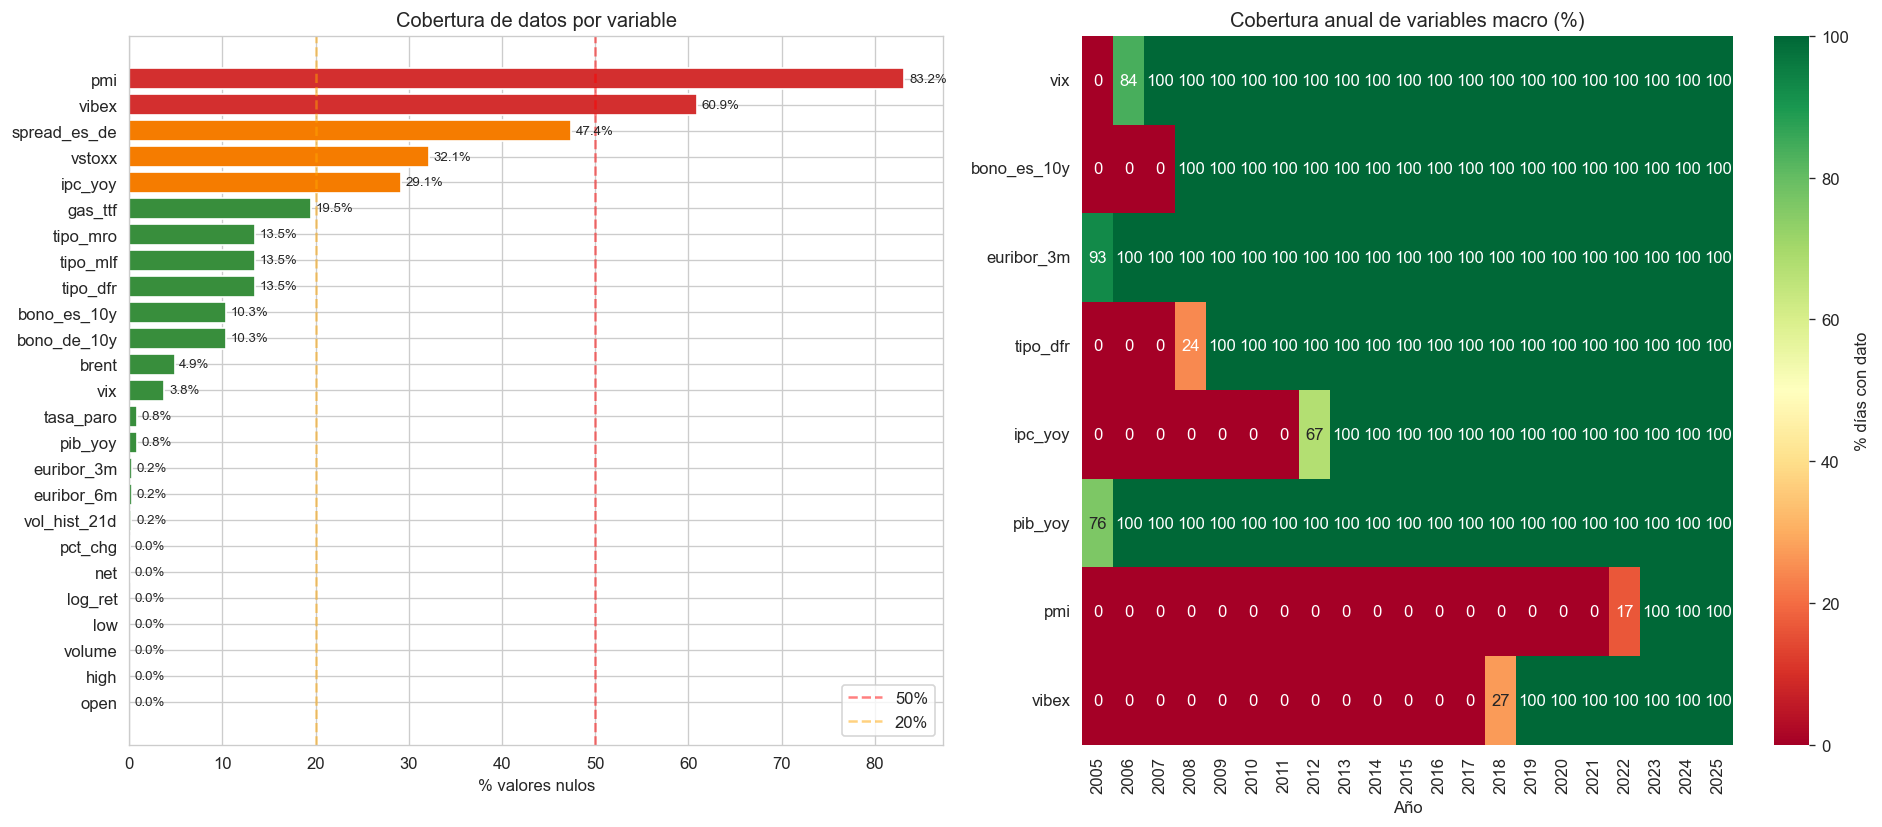

Figura guardada: 01_cobertura_datos.png


In [11]:
# Heatmap de cobertura de datos por variable y año
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -- Panel izq: % nulos por variable
nulos_pct = df.isnull().mean() * 100
nulos_pct = nulos_pct[nulos_pct > 0].sort_values(ascending=True)
colors = ['#d32f2f' if v > 50 else '#f57c00' if v > 20 else '#388e3c' for v in nulos_pct]
axes[0].barh(nulos_pct.index, nulos_pct.values, color=colors)
axes[0].axvline(50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[0].axvline(20, color='orange', linestyle='--', alpha=0.5, label='20%')
axes[0].set_xlabel('% valores nulos')
axes[0].set_title('Cobertura de datos por variable')
axes[0].legend()
for i, v in enumerate(nulos_pct.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

# -- Panel der: cobertura temporal de variables macro clave
macro_vars = ['vix', 'bono_es_10y', 'euribor_3m', 'tipo_dfr', 'ipc_yoy', 'pib_yoy', 'pmi', 'vibex']
df_plot = df[['fecha'] + macro_vars].drop_duplicates('fecha').set_index('fecha')
df_cov = df_plot.notna().resample('YE').mean() * 100
sns.heatmap(df_cov.T, ax=axes[1], cmap='RdYlGn', vmin=0, vmax=100,
            annot=True, fmt='.0f', cbar_kws={'label': '% días con dato'},
            xticklabels=[str(d.year) for d in df_cov.index])
axes[1].set_title('Cobertura anual de variables macro (%)')
axes[1].set_xlabel('Año')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_cobertura_datos.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 01_cobertura_datos.png')

## 5. Antes/Después — Transformación de precios a log-retornos


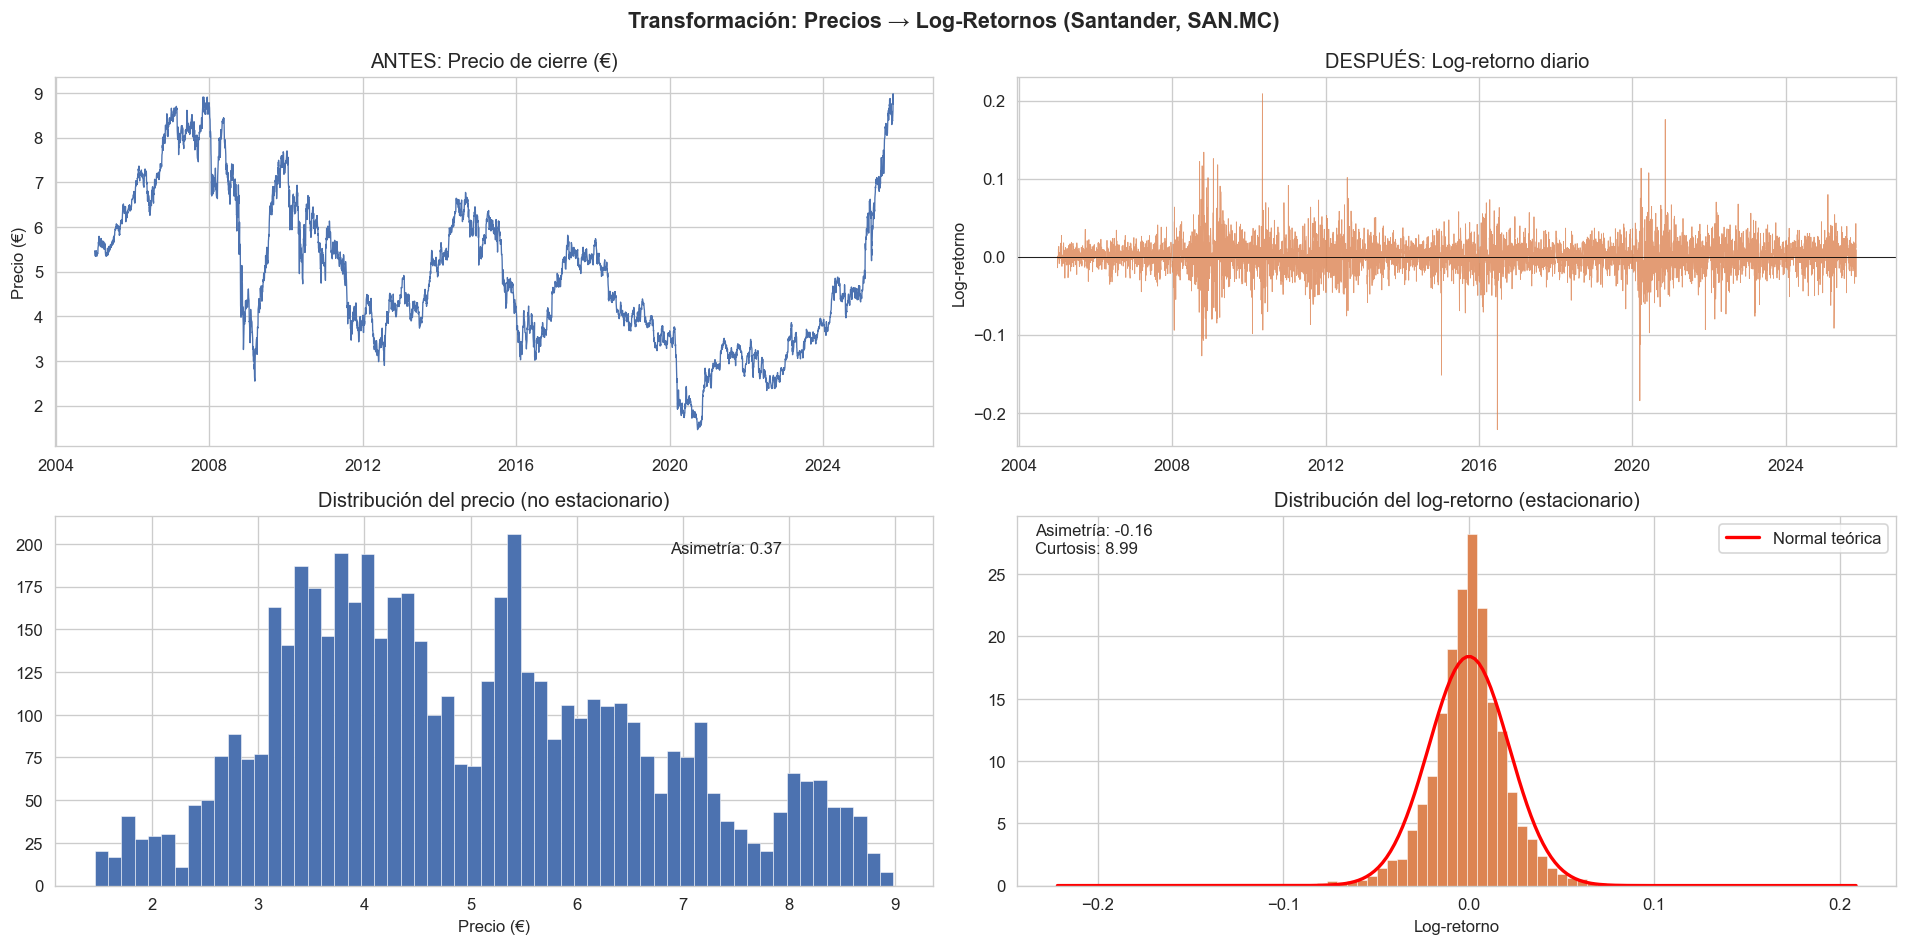

Figura guardada: 02_antes_despues_logretos.png


In [13]:
# Empresa ejemplo: Santander
san = df[df['ticker'] == 'SAN.MC'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Transformación: Precios → Log-Retornos (Santander, SAN.MC)', fontsize=13, fontweight='bold')

# Antes: precio de cierre
axes[0,0].plot(san['fecha'], san['close'], color=COLORS[0], linewidth=0.8)
axes[0,0].set_title('ANTES: Precio de cierre (€)')
axes[0,0].set_ylabel('Precio (€)')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Después: log-retorno
axes[0,1].plot(san['fecha'], san['log_ret'], color=COLORS[1], linewidth=0.5, alpha=0.8)
axes[0,1].axhline(0, color='black', linewidth=0.5)
axes[0,1].set_title('DESPUÉS: Log-retorno diario')
axes[0,1].set_ylabel('Log-retorno')
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Distribución antes
axes[1,0].hist(san['close'].dropna(), bins=60, color=COLORS[0], edgecolor='white', linewidth=0.3)
axes[1,0].set_title('Distribución del precio (no estacionario)')
axes[1,0].set_xlabel('Precio (€)')
skew_price = san['close'].dropna().skew()
axes[1,0].text(0.7, 0.9, f'Asimetría: {skew_price:.2f}', transform=axes[1,0].transAxes)

# Distribución después
lr = san['log_ret'].dropna()
axes[1,1].hist(lr, bins=80, color=COLORS[1], edgecolor='white', linewidth=0.3, density=True)
x = np.linspace(lr.min(), lr.max(), 200)
axes[1,1].plot(x, stats.norm.pdf(x, lr.mean(), lr.std()), 'r-', linewidth=2, label='Normal teórica')
axes[1,1].set_title('Distribución del log-retorno (estacionario)')
axes[1,1].set_xlabel('Log-retorno')
skew_lr = lr.skew()
kurt_lr = lr.kurtosis()
axes[1,1].text(0.02, 0.9, f'Asimetría: {skew_lr:.2f}\nCurtosis: {kurt_lr:.2f}', transform=axes[1,1].transAxes)
axes[1,1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_antes_despues_logretos.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 02_antes_despues_logretos.png')

## 6. Antes/Después — Interpolación de valores nulos en precios

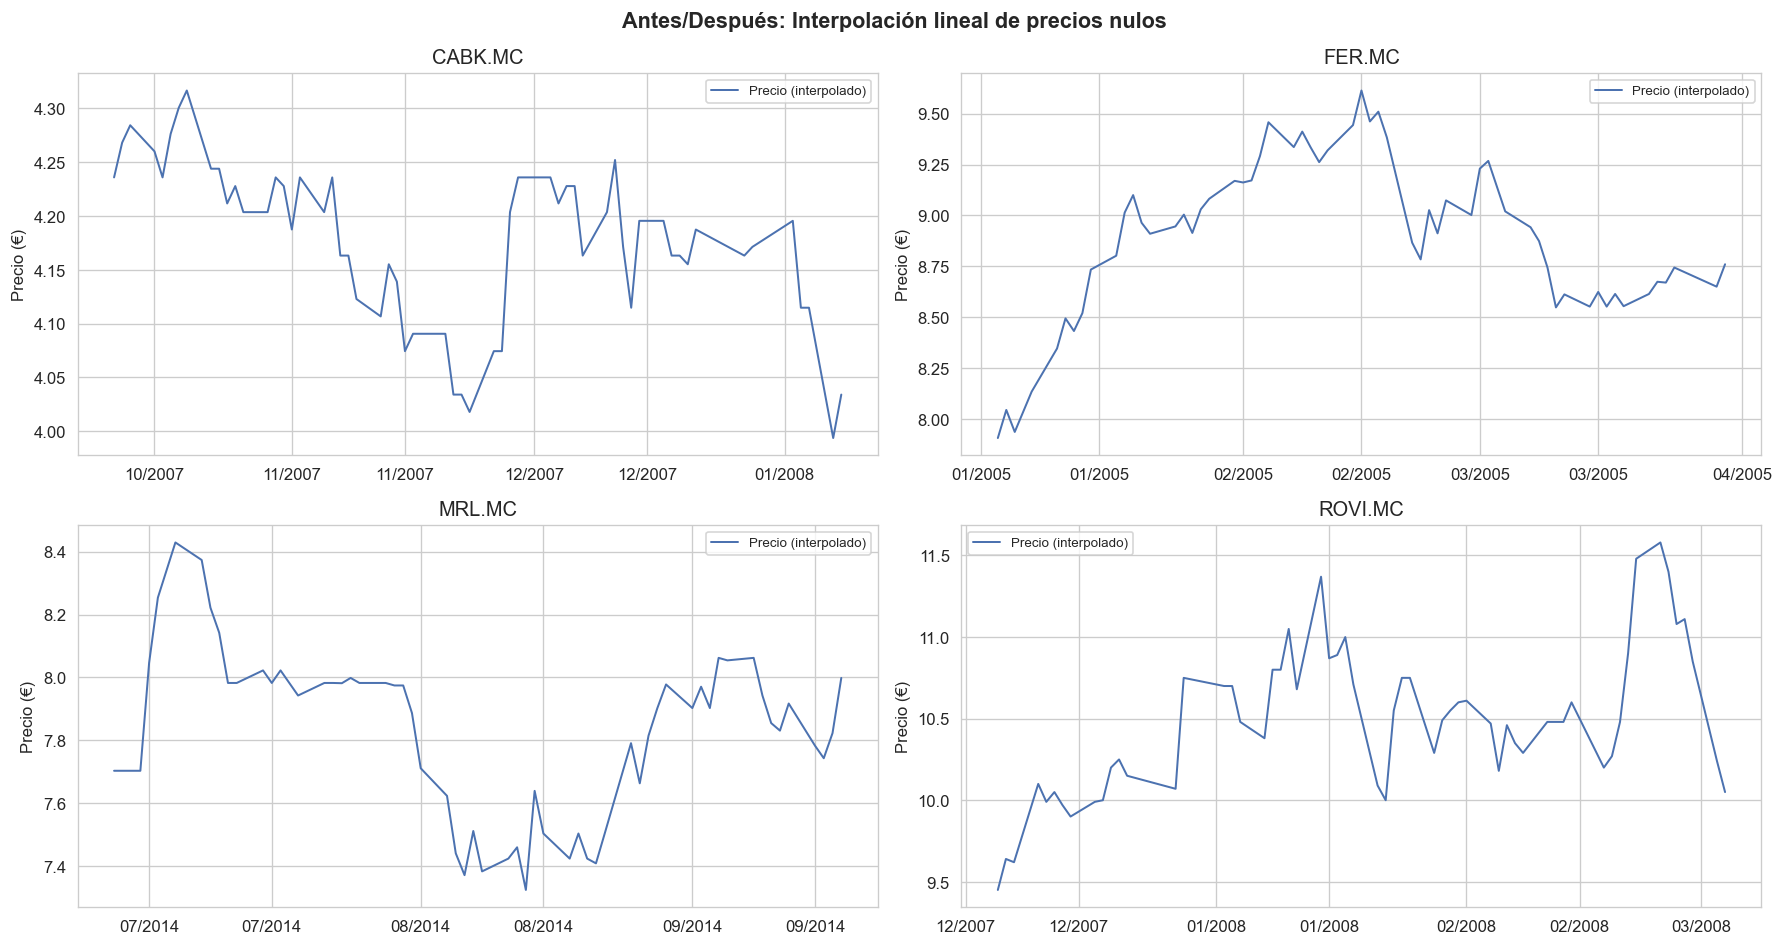

Figura guardada: 03_interpolacion_nulos.png

Empresas con precios interpolados y nulos originales:
  CABK.MC: 1 nulo  |  FER.MC: 1 nulo  |  MRL.MC: 1 nulo  |  ROVI.MC: 5 nulos
Método: interpolación lineal con pandas .interpolate(method="linear")


In [14]:
# Mostrar las 8 filas que tenían nulos en close y cómo quedaron tras interpolación
tickers_nulos = ['CABK.MC', 'FER.MC', 'MRL.MC', 'ROVI.MC']
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('Antes/Después: Interpolación lineal de precios nulos', fontsize=13, fontweight='bold')

for ax, ticker in zip(axes.flat, tickers_nulos):
    sub = df[df['ticker'] == ticker][['fecha', 'close']].copy()
    sub = sub.sort_values('fecha').reset_index(drop=True)
    # Ventana de 40 días alrededor del primer valor (que era nulo antes)
    # El valor interpolado se puede identificar como el que no tiene vecinos iguales
    # Tomamos las primeras 60 observaciones para visualizar
    sub_plot = sub.head(60)
    ax.plot(sub_plot['fecha'], sub_plot['close'], color=COLORS[0], linewidth=1.2, label='Precio (interpolado)')
    ax.set_title(f'{ticker}')
    ax.set_ylabel('Precio (€)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_interpolacion_nulos.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 03_interpolacion_nulos.png')
print()
print('Empresas con precios interpolados y nulos originales:')
print('  CABK.MC: 1 nulo  |  FER.MC: 1 nulo  |  MRL.MC: 1 nulo  |  ROVI.MC: 5 nulos')
print('Método: interpolación lineal con pandas .interpolate(method="linear")')

## 7. Distribución de log-retornos — todas las empresas

Estadísticos de log-retornos por empresa:
           media     std  asimetria  curtosis     n
ticker                                             
ACS.MC    0.0004  0.0188    -0.0703   13.7059  5322
ACX.MC    0.0000  0.0190    -0.0900    3.6600  5322
AENA.MC   0.0004  0.0171    -0.8984   22.0690  2744
AMA.MC    0.0004  0.0172    -0.1719    8.8086  3970
ANA.MC    0.0002  0.0210    -0.3415    5.7170  5322
ANE.MC   -0.0002  0.0194    -0.0238    0.7727  1111
BBVA.MC   0.0001  0.0215    -0.0649    7.1255  5322
BKT.MC    0.0003  0.0213     0.2250    5.0241  5322
CABK.MC   0.0002  0.0211    -0.2126    5.8720  4614
CLNX.MC   0.0003  0.0175     0.0799    3.6119  2686
COL.MC   -0.0006  0.0323     0.3884   16.9984  5321
ELE.MC    0.0002  0.0159    -2.1765   42.0662  5322
ENAG.MC   0.0000  0.0146    -0.6538    8.2859  5322
FER.MC    0.0004  0.0188    -0.2016    5.3941  5321
FLUI.MC   0.0003  0.0226    -0.0966    5.6980  4599
GRLS.MC   0.0003  0.0224    -1.9985   39.2745  4973
IBE.MC    0.0004  0.01

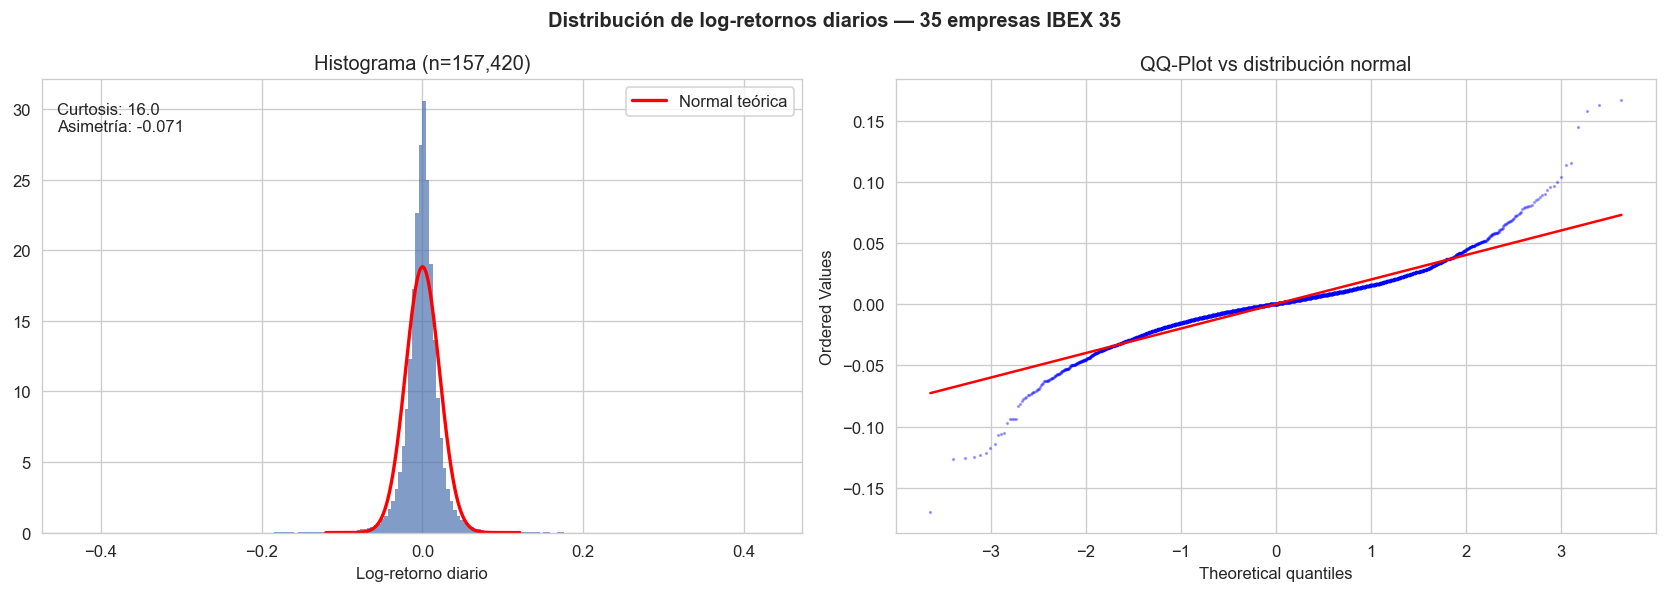

Figura guardada: 04_distribucion_logreturns.png


In [15]:
# Estadísticos de log-retornos por empresa
lr_stats = df.groupby('ticker')['log_ret'].agg(
    media='mean', std='std', asimetria='skew',
    curtosis=lambda x: x.kurtosis(), n='count'
).round(4)

print('Estadísticos de log-retornos por empresa:')
print(lr_stats.to_string())
print()
print(f'Media de std (volatilidad diaria media): {lr_stats["std"].mean():.4f}')
print(f'Media de curtosis: {lr_stats["curtosis"].mean():.2f}  (Normal=3, >3=colas pesadas)')

# Distribución conjunta de todos los log-retornos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de log-retornos diarios — 35 empresas IBEX 35', fontsize=12, fontweight='bold')

lr_all = df['log_ret'].dropna()
axes[0].hist(lr_all, bins=200, density=True, color=COLORS[0], alpha=0.7, edgecolor='none')
x = np.linspace(lr_all.quantile(0.001), lr_all.quantile(0.999), 500)
axes[0].plot(x, stats.norm.pdf(x, lr_all.mean(), lr_all.std()), 'r-', lw=2, label='Normal teórica')
axes[0].set_xlabel('Log-retorno diario')
axes[0].set_title(f'Histograma (n={len(lr_all):,})')
axes[0].legend()
axes[0].text(0.02, 0.95, f'Curtosis: {lr_all.kurtosis():.1f}\nAsimetría: {lr_all.skew():.3f}',
             transform=axes[0].transAxes, va='top')

# QQ-plot
stats.probplot(lr_all.sample(5000, random_state=42), dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot vs distribución normal')
axes[1].get_lines()[0].set(markersize=1, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_distribucion_logreturns.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 04_distribucion_logreturns.png')

## 8. Volatilidad histórica — evolución temporal

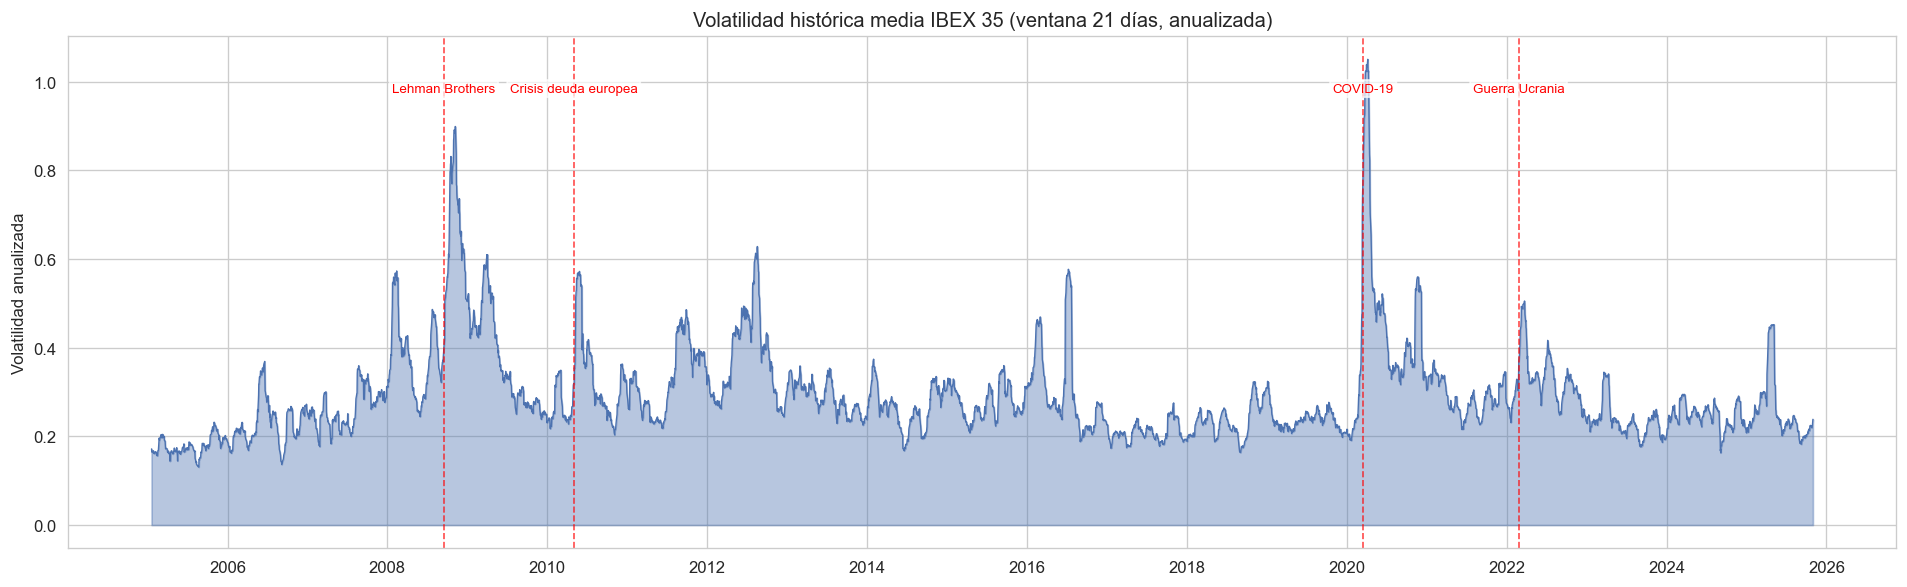

Figura guardada: 05_volatilidad_temporal.png


In [18]:
# Volatilidad media del IBEX 35 (promedio de las 35 empresas por día)                                                                                                                                                                                                                        
vol_ibex = df.groupby('fecha')['vol_hist_21d'].mean().reset_index()                                                                                                                                                                                                                        
vol_ibex.columns = ['fecha', 'vol_media']                                                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                                                               
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(vol_ibex['fecha'], vol_ibex['vol_media'], alpha=0.4, color=COLORS[0])
ax.plot(vol_ibex['fecha'], vol_ibex['vol_media'], color=COLORS[0], linewidth=0.8)

  # Marcar eventos clave
eventos = {
      '2008-09-15': 'Lehman Brothers',
      '2010-05-01': 'Crisis deuda europea',
      '2020-03-16': 'COVID-19',
      '2022-02-24': 'Guerra Ucrania'
  }
for fecha, label in eventos.items():
      fecha_dt = pd.to_datetime(fecha)
      ax.axvline(fecha_dt, color='red', linestyle='--', linewidth=1, alpha=0.7)
      ax.text(fecha_dt, vol_ibex['vol_media'].max() * 0.95, label,
              ha='center', va='top', fontsize=8, color='red',
              bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title('Volatilidad histórica media IBEX 35 (ventana 21 días, anualizada)', fontsize=12)
ax.set_ylabel('Volatilidad anualizada')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_volatilidad_temporal.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 05_volatilidad_temporal.png')


## 9. Volatilidad por empresa y sector

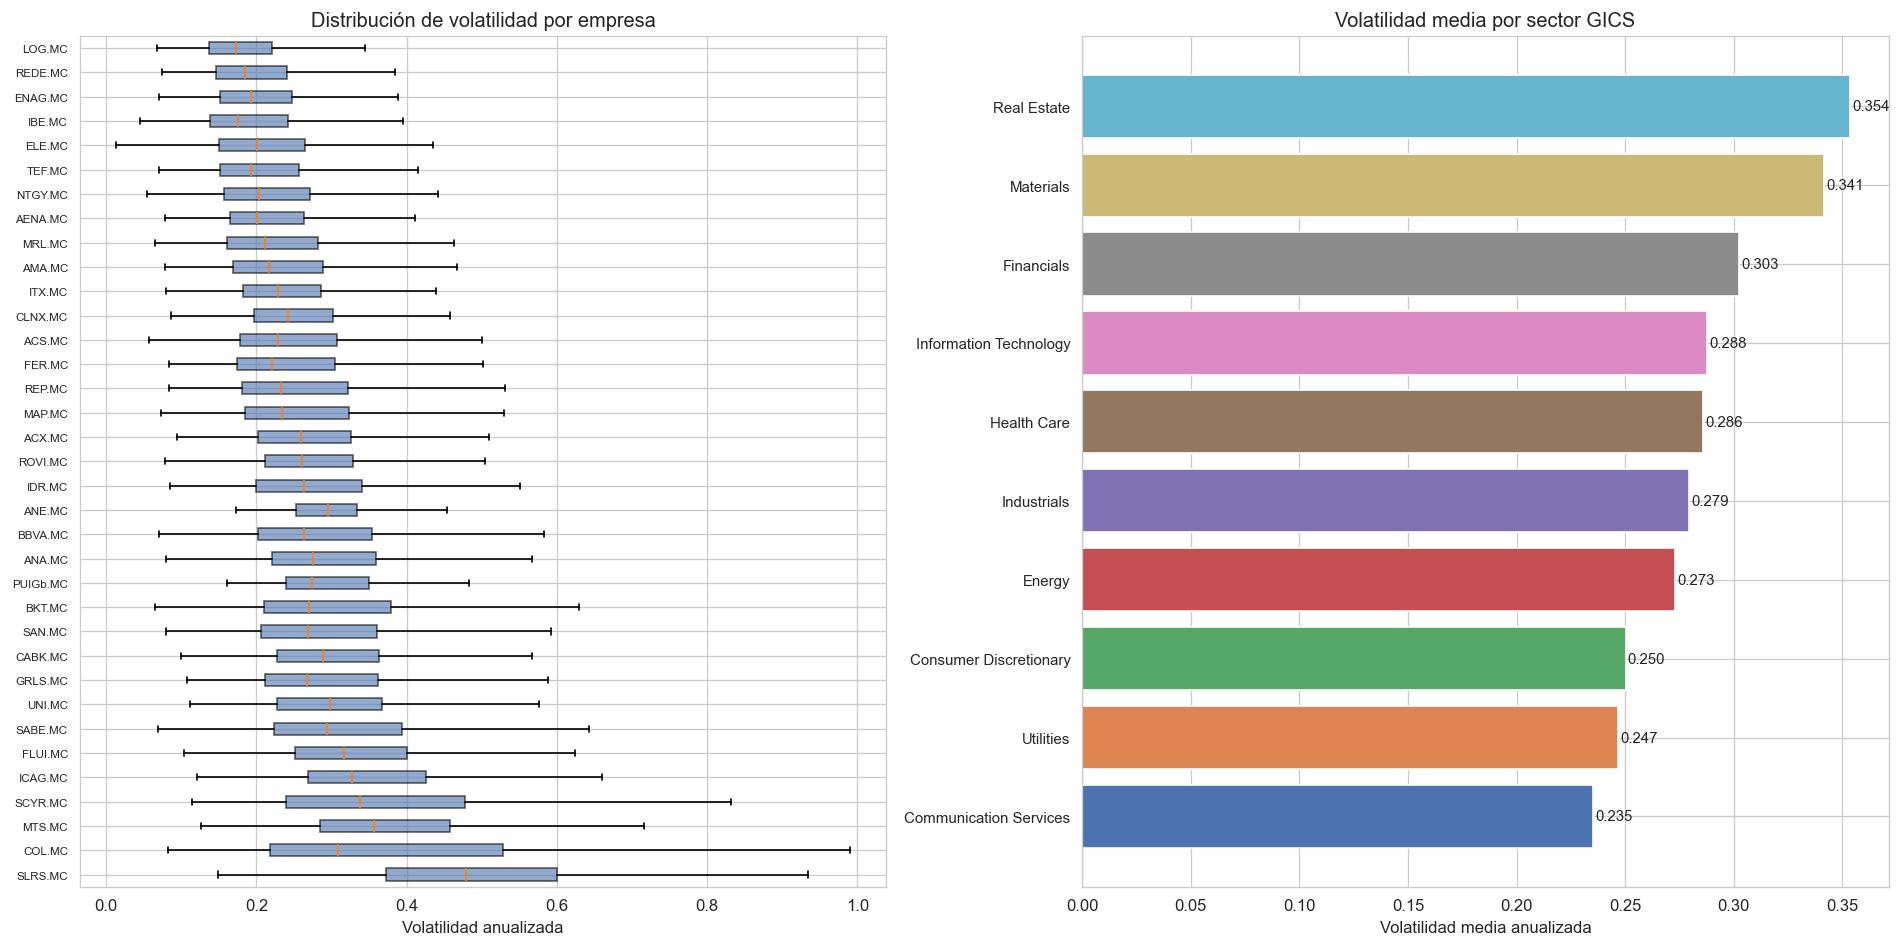

Figura guardada: 06_volatilidad_empresa_sector.png


In [22]:
df_ref_fix = df_ref.copy()                                                                                                                                                                                                                                                                   
df_ref_fix['ticker'] = df_ref_fix['ticker'].astype(str) + '.MC'
df_ref_fix = df_ref_fix.dropna(subset=['ticker','sector'])                                                                                                                                                                                                                                   
                                                                                                                                                                                                                                                                                             
df_with_sector = df.merge(df_ref_fix[['ticker','sector']], on='ticker', how='left')

  # Volatilidad media por empresa
vol_empresa = df_with_sector.groupby('ticker')['vol_hist_21d'].mean().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

  # Boxplot por empresa
tickers_ord = vol_empresa['ticker'].tolist()
data_box = [df_with_sector[df_with_sector['ticker']==t]['vol_hist_21d'].dropna().values for t in tickers_ord]
bp = axes[0].boxplot(data_box, patch_artist=True, vert=False, showfliers=False,
                       boxprops=dict(facecolor=COLORS[0], alpha=0.6))
axes[0].set_yticks(range(1, len(tickers_ord)+1))
axes[0].set_yticklabels(tickers_ord, fontsize=7)
axes[0].set_xlabel('Volatilidad anualizada')
axes[0].set_title('Distribución de volatilidad por empresa')

  # Media por sector
vol_sector = df_with_sector.groupby('sector')['vol_hist_21d'].mean().sort_values()
axes[1].barh(range(len(vol_sector)), vol_sector.values, color=COLORS[:len(vol_sector)])
axes[1].set_yticks(range(len(vol_sector)))
axes[1].set_yticklabels(vol_sector.index, fontsize=9)
axes[1].set_xlabel('Volatilidad media anualizada')
axes[1].set_title('Volatilidad media por sector GICS')
for i, v in enumerate(vol_sector.values):
      axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_volatilidad_empresa_sector.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 06_volatilidad_empresa_sector.png')

## 10. Evolución de variables macroeconómicas

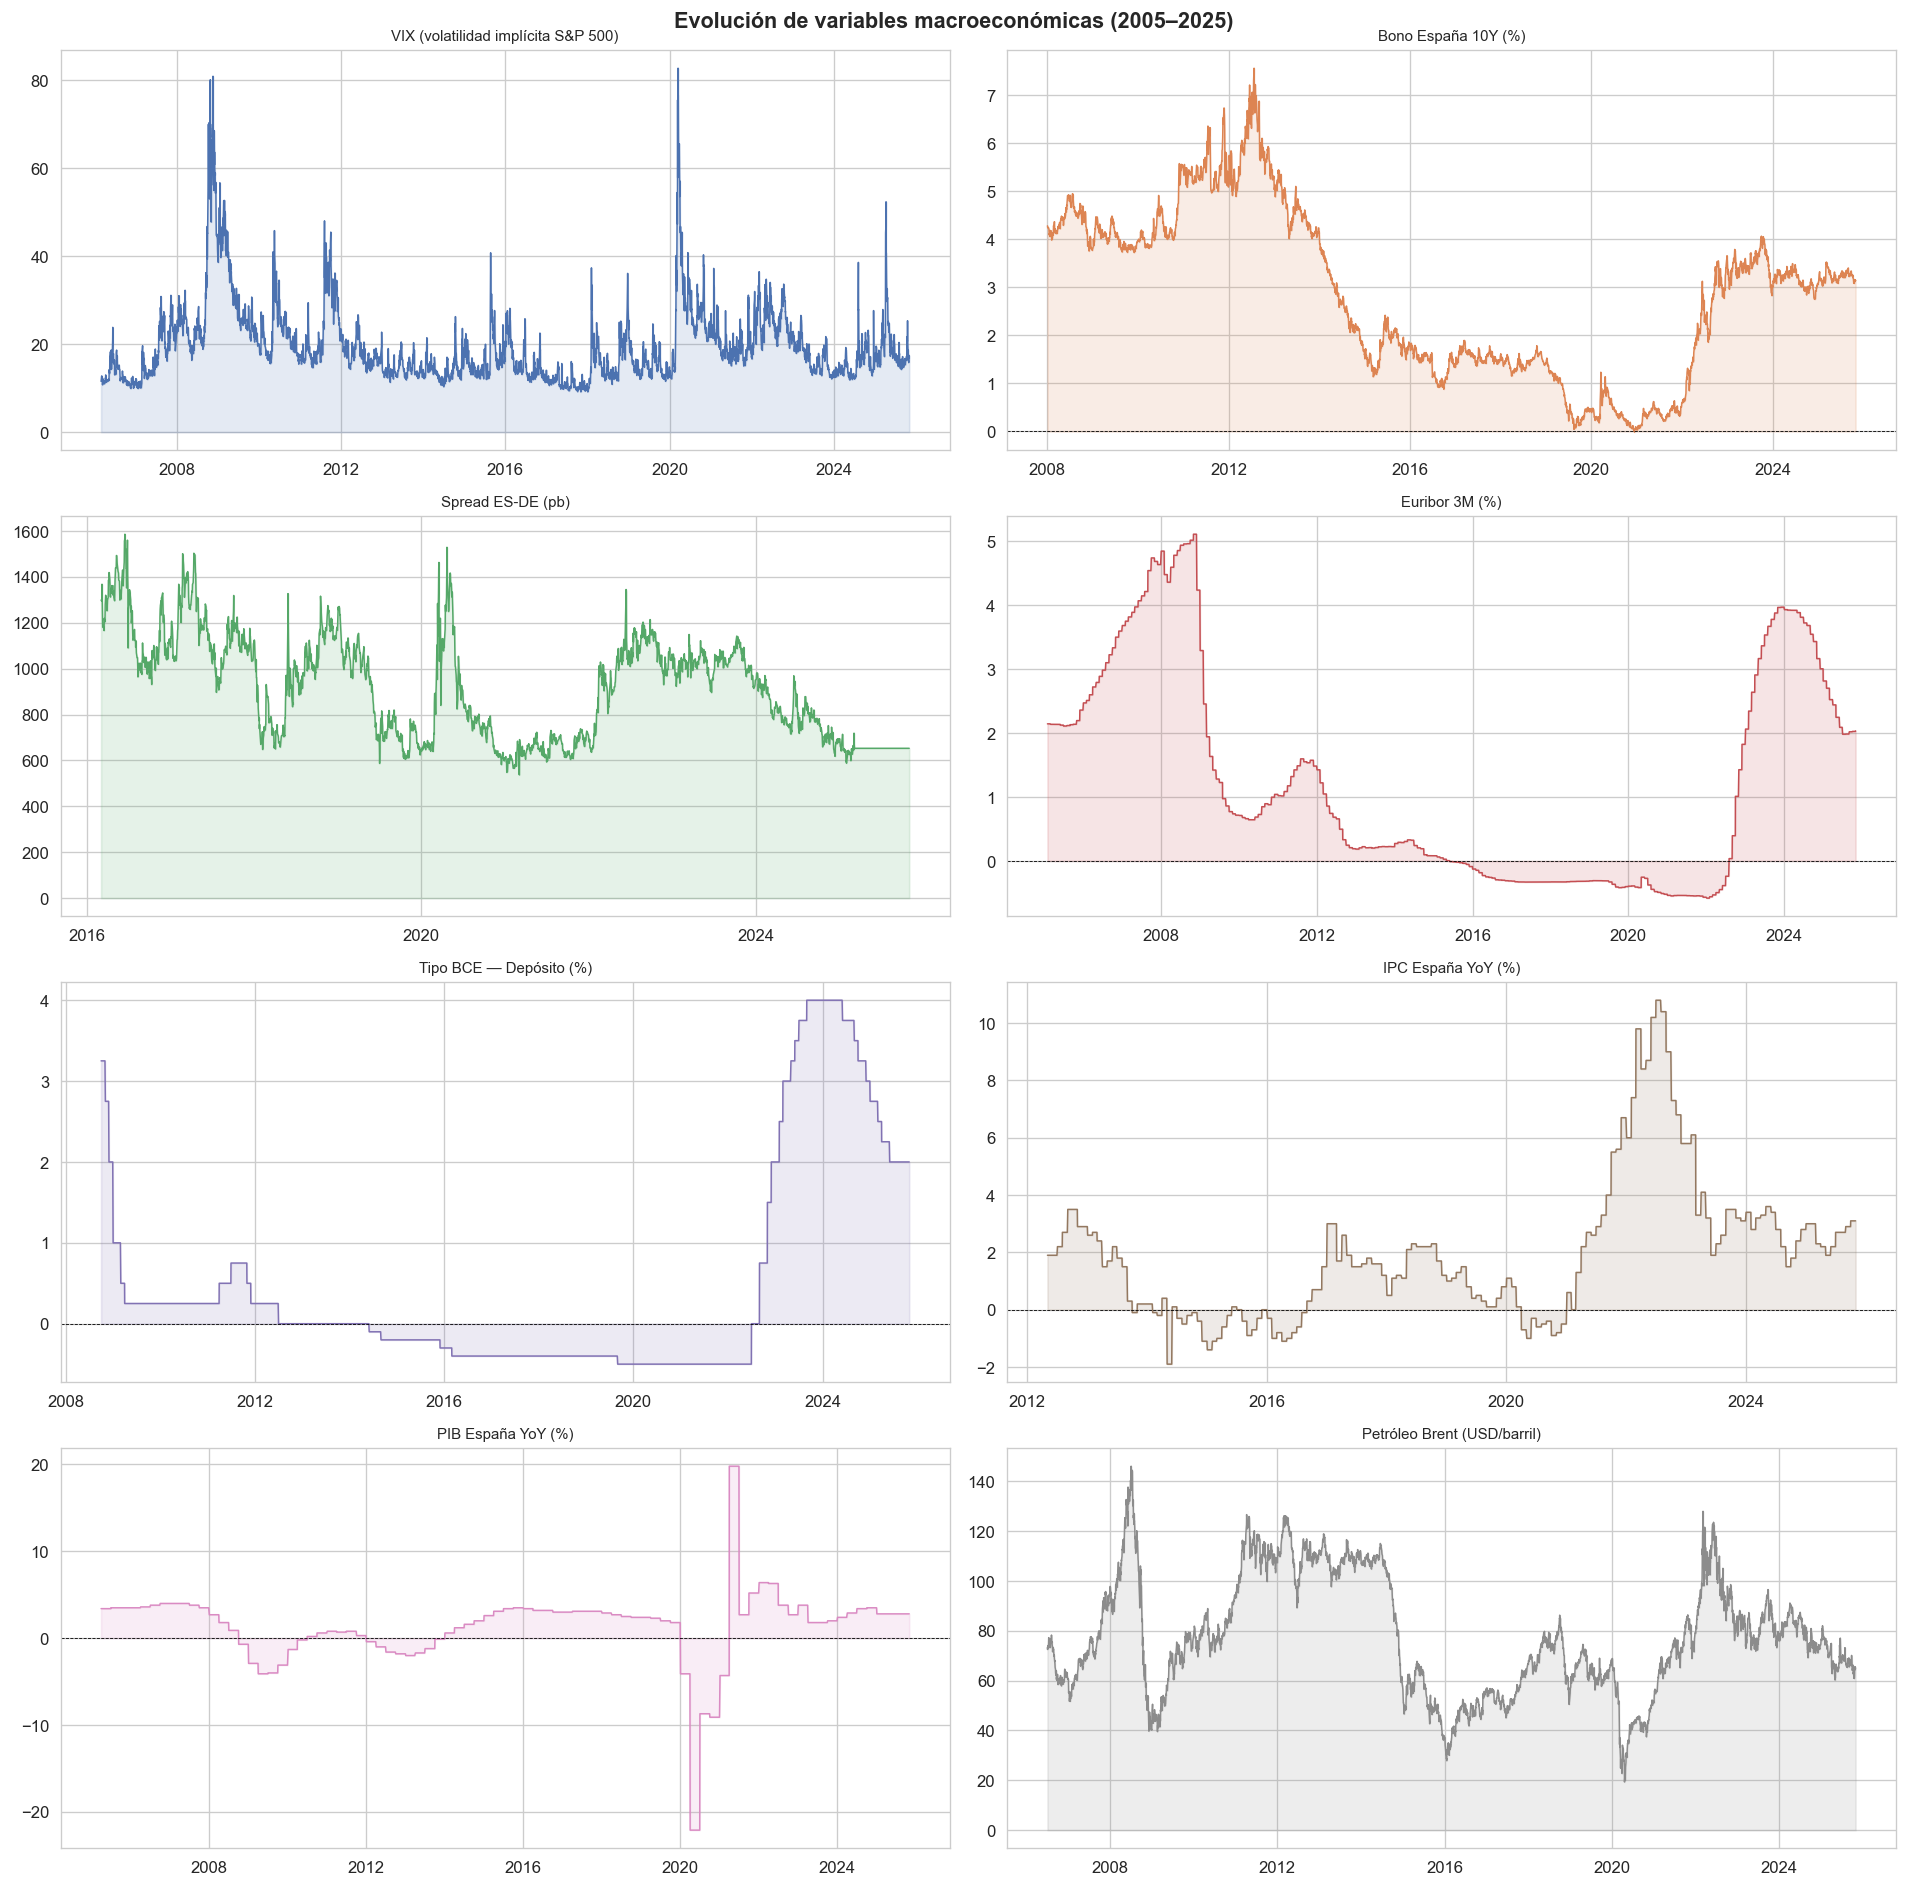

Figura guardada: 07_macro_evolucion.png


In [23]:
# Variables macro clave — una observación por fecha
macro_daily = df.drop_duplicates('fecha').sort_values('fecha').set_index('fecha')

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
fig.suptitle('Evolución de variables macroeconómicas (2005–2025)', fontsize=13, fontweight='bold')

vars_plot = [
    ('vix',          'VIX (volatilidad implícita S&P 500)',    COLORS[0]),
    ('bono_es_10y',  'Bono España 10Y (%)',                    COLORS[1]),
    ('spread_es_de', 'Spread ES-DE (pb)',                      COLORS[2]),
    ('euribor_3m',   'Euribor 3M (%)',                         COLORS[3]),
    ('tipo_dfr',     'Tipo BCE — Depósito (%)',                 COLORS[4]),
    ('ipc_yoy',      'IPC España YoY (%)',                      COLORS[5]),
    ('pib_yoy',      'PIB España YoY (%)',                      COLORS[6]),
    ('brent',        'Petróleo Brent (USD/barril)',             COLORS[7]),
]

for ax, (var, titulo, color) in zip(axes.flat, vars_plot):
    serie = macro_daily[var].dropna()
    ax.plot(serie.index, serie.values, color=color, linewidth=0.9)
    ax.fill_between(serie.index, serie.values, alpha=0.15, color=color)
    ax.set_title(titulo, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    if var in ['tipo_dfr', 'euribor_3m', 'bono_es_10y', 'ipc_yoy', 'pib_yoy']:
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '07_macro_evolucion.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 07_macro_evolucion.png')

## 11. Estudio de series temporales — Test de estacionariedad (ADF)

In [24]:
def adf_test(serie, nombre):
    serie_clean = serie.dropna()
    resultado = adfuller(serie_clean, autolag='AIC')
    p_valor = resultado[1]
    estacionaria = 'SI' if p_valor < 0.05 else 'NO'
    return {
        'Variable': nombre,
        'Estadístico ADF': round(resultado[0], 4),
        'p-valor': round(p_valor, 4),
        '¿Estacionaria? (p<0.05)': estacionaria
    }

# Testar estacionariedad en variables clave
san = df[df['ticker'] == 'SAN.MC'].sort_values('fecha')
macro = df.drop_duplicates('fecha').sort_values('fecha')

tests = [
    (san['close'],          'Precio cierre (SAN.MC)'),
    (san['log_ret'],        'Log-retorno (SAN.MC)'),
    (san['vol_hist_21d'],   'Volatilidad hist. 21d (SAN.MC)'),
    (macro['vix'],          'VIX'),
    (macro['bono_es_10y'],  'Bono ES 10Y'),
    (macro['euribor_3m'],   'Euribor 3M'),
    (macro['ipc_yoy'],      'IPC YoY'),
    (macro['pib_yoy'],      'PIB YoY'),
]

resultados = [adf_test(serie, nombre) for serie, nombre in tests]
df_adf = pd.DataFrame(resultados)
print('=== TEST DE DICKEY-FULLER AUMENTADO (ADF) ===')
print('H0: La serie tiene raíz unitaria (NO es estacionaria)')
print('Rechazo H0 si p-valor < 0.05')
print()
print(df_adf.to_string(index=False))
print()
print('CONCLUSIONES:')
estac = df_adf[df_adf['¿Estacionaria? (p<0.05)'] == 'SI']['Variable'].tolist()
no_estac = df_adf[df_adf['¿Estacionaria? (p<0.05)'] == 'NO']['Variable'].tolist()
print(f'  Estacionarias : {estac}')
print(f'  No estacionarias: {no_estac}')

=== TEST DE DICKEY-FULLER AUMENTADO (ADF) ===
H0: La serie tiene raíz unitaria (NO es estacionaria)
Rechazo H0 si p-valor < 0.05

                      Variable  Estadístico ADF  p-valor ¿Estacionaria? (p<0.05)
        Precio cierre (SAN.MC)          -1.7282   0.4166                      NO
          Log-retorno (SAN.MC)         -43.2384   0.0000                      SI
Volatilidad hist. 21d (SAN.MC)          -6.1675   0.0000                      SI
                           VIX          -5.5981   0.0000                      SI
                   Bono ES 10Y          -1.3617   0.6005                      NO
                    Euribor 3M          -1.9140   0.3255                      NO
                       IPC YoY          -1.7157   0.4230                      NO
                       PIB YoY          -4.4767   0.0002                      SI

CONCLUSIONES:
  Estacionarias : ['Log-retorno (SAN.MC)', 'Volatilidad hist. 21d (SAN.MC)', 'VIX', 'PIB YoY']
  No estacionarias: ['Precio ci

## 12. ACF y PACF de la volatilidad

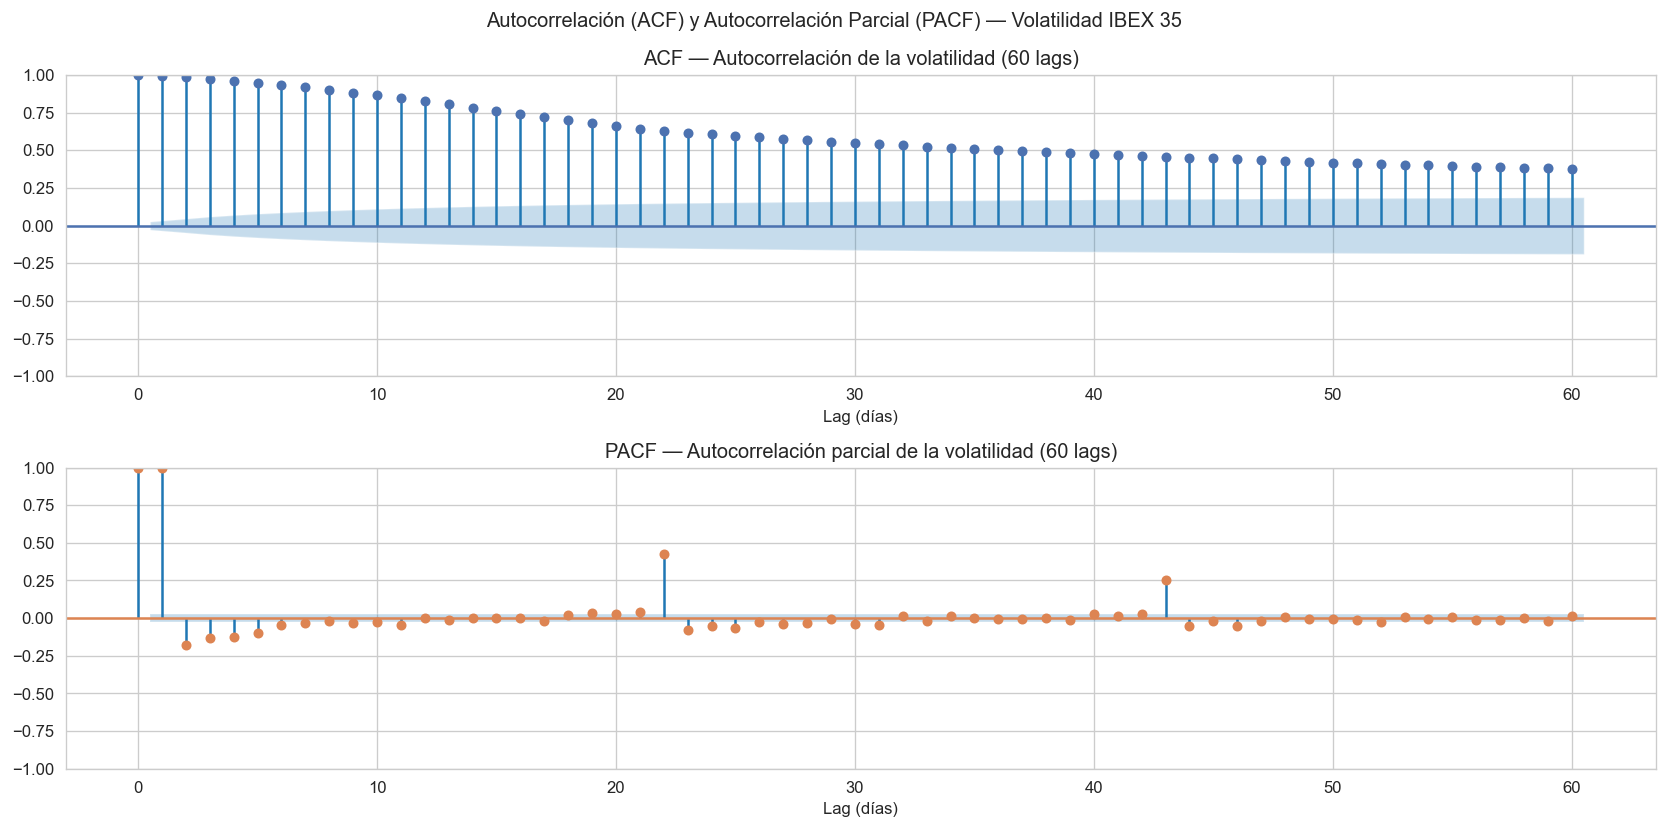

Figura guardada: 08_acf_pacf_volatilidad.png

La persistencia en ACF confirma que la volatilidad tiene memoria larga -> justifica modelos GARCH


In [25]:
# ACF/PACF de la volatilidad histórica (promedio IBEX)
vol_ibex = df.groupby('fecha')['vol_hist_21d'].mean().dropna().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('Autocorrelación (ACF) y Autocorrelación Parcial (PACF) — Volatilidad IBEX 35', fontsize=12)

plot_acf(vol_ibex, lags=60, ax=axes[0], color=COLORS[0], alpha=0.05)
axes[0].set_title('ACF — Autocorrelación de la volatilidad (60 lags)')
axes[0].set_xlabel('Lag (días)')

plot_pacf(vol_ibex, lags=60, ax=axes[1], color=COLORS[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — Autocorrelación parcial de la volatilidad (60 lags)')
axes[1].set_xlabel('Lag (días)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '08_acf_pacf_volatilidad.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 08_acf_pacf_volatilidad.png')
print()
print('La persistencia en ACF confirma que la volatilidad tiene memoria larga -> justifica modelos GARCH')

## 13. Correlaciones — Variables macro vs Volatilidad

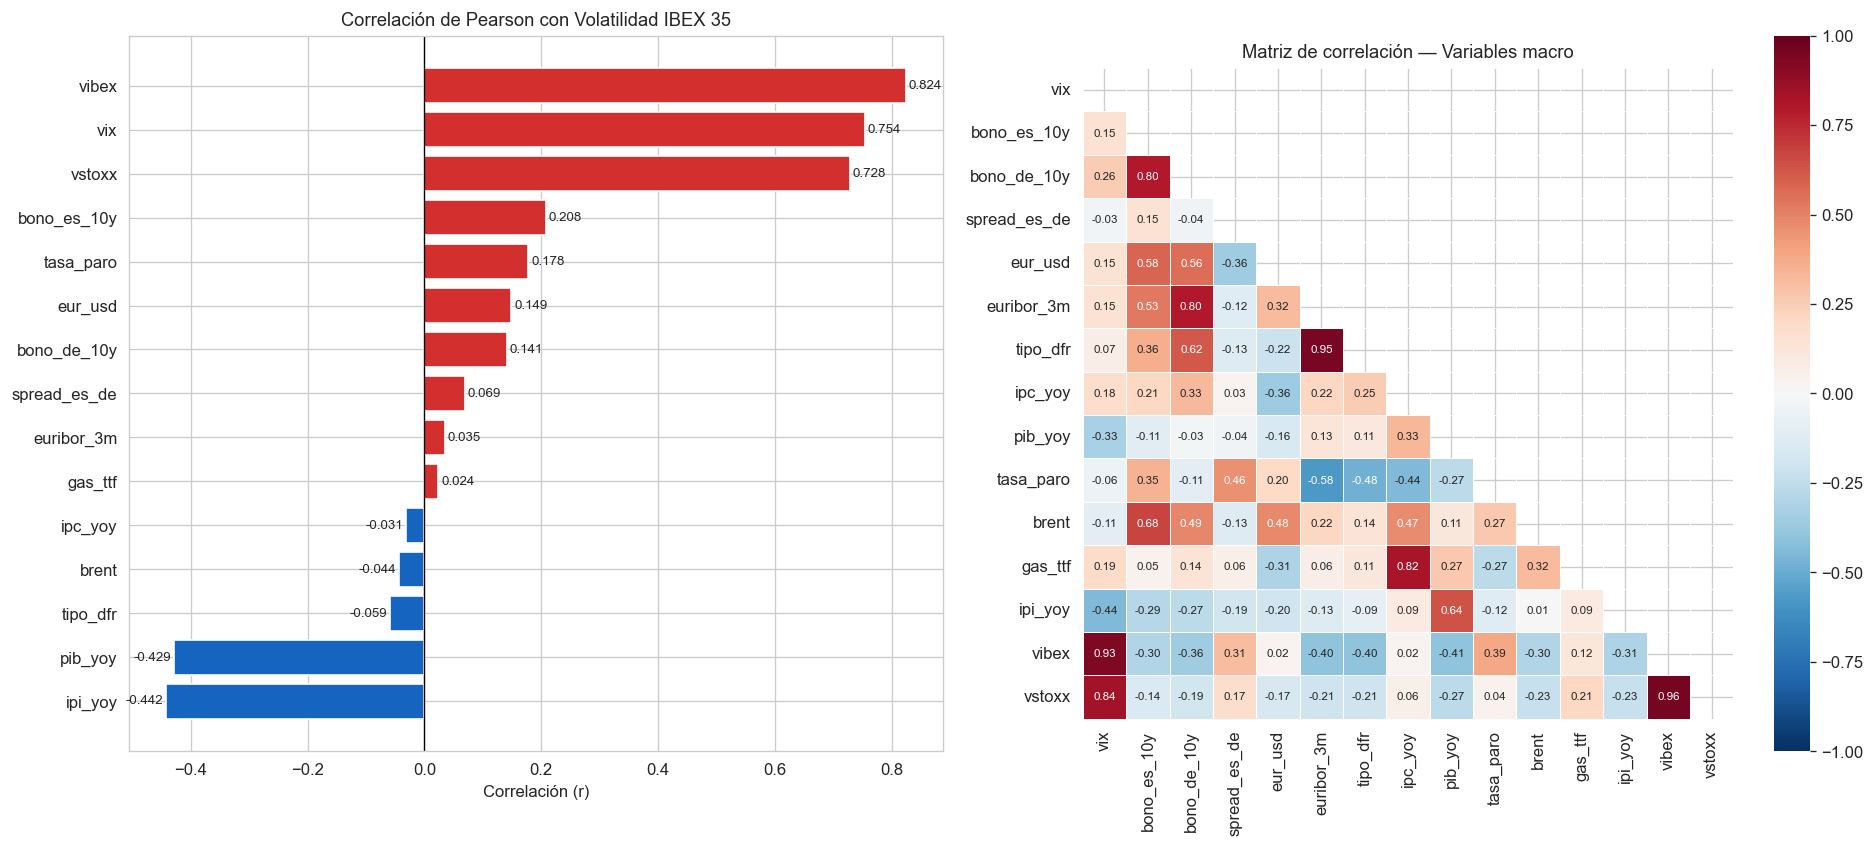

Figura guardada: 09_correlaciones_macro_vol.png

Top 5 correlaciones positivas con volatilidad IBEX:
tasa_paro      0.177627
bono_es_10y    0.207765
vstoxx         0.728321
vix            0.754484
vibex          0.823918

Top 5 correlaciones negativas con volatilidad IBEX:
ipi_yoy    -0.442280
pib_yoy    -0.429024
tipo_dfr   -0.058960
brent      -0.043847
ipc_yoy    -0.031441


In [26]:
# Dataset diario único para correlaciones (una obs por fecha)
macro_unique = df.drop_duplicates('fecha').sort_values('fecha')
vol_media = df.groupby('fecha')['vol_hist_21d'].mean().reset_index()
vol_media.columns = ['fecha', 'vol_media_ibex']
macro_corr = macro_unique.merge(vol_media, on='fecha')

vars_macro = ['vix','bono_es_10y','bono_de_10y','spread_es_de','eur_usd',
              'euribor_3m','tipo_dfr','ipc_yoy','pib_yoy','tasa_paro',
              'brent','gas_ttf','ipi_yoy','vibex','vstoxx']
vars_macro = [v for v in vars_macro if v in macro_corr.columns]

corr_vol = macro_corr[vars_macro + ['vol_media_ibex']].corr()['vol_media_ibex'].drop('vol_media_ibex').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Barras de correlación con volatilidad
colors_bar = ['#d32f2f' if v > 0 else '#1565c0' for v in corr_vol.values]
axes[0].barh(corr_vol.index, corr_vol.values, color=colors_bar)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlación de Pearson con Volatilidad IBEX 35', fontsize=11)
axes[0].set_xlabel('Correlación (r)')
for i, v in enumerate(corr_vol.values):
    axes[0].text(v + 0.005 if v >= 0 else v - 0.005, i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# Matriz de correlación completa
corr_matrix = macro_corr[vars_macro].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7},
            square=True, linewidths=0.3)
axes[1].set_title('Matriz de correlación — Variables macro', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '09_correlaciones_macro_vol.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 09_correlaciones_macro_vol.png')
print()
print('Top 5 correlaciones positivas con volatilidad IBEX:')
print(corr_vol[corr_vol > 0].tail(5).to_string())
print()
print('Top 5 correlaciones negativas con volatilidad IBEX:')
print(corr_vol[corr_vol < 0].head(5).to_string())

## 14. Resumen ejecutivo del EDA

In [ ]:
print('=' * 65)
print('RESUMEN EJECUTIVO — ANÁLISIS EXPLORATORIO')
print('=' * 65)
print()
print('DATASET MAESTRO:')
print(f'  Filas         : {len(df):,}')
print(f'  Columnas      : {df.shape[1]}')
print(f'  Período       : 2005-01-03 → 2025-10-31 (20 años)')
print(f'  Empresas      : {df["ticker"].nunique()} (IBEX 35)')
print(f'  Días trading  : {df["fecha"].nunique():,}')
print()
print('CALIDAD DE DATOS:')
print(f'  Duplicados (ticker+fecha): 0')
print(f'  Precios nulos interpolados: 8 (CABK, FER, MRL, ROVI)')
print(f'  Variables con cobertura >90%: {(df.isnull().mean() < 0.10).sum()}')
print(f'  Variables con cobertura >70%: {(df.isnull().mean() < 0.30).sum()}')
print()
print('PROPIEDADES ESTADÍSTICAS:')
lr = df['log_ret'].dropna()
print(f'  Log-retornos: media={lr.mean():.5f}, std={lr.std():.4f}')
print(f'  Curtosis log-ret: {lr.kurtosis():.2f} (leptocúrtica, colas pesadas)')
print(f'  Log-retornos estacionarios: SI (ADF p<0.05)')
print(f'  Precios NO estacionarios: SI (ADF p>0.05) → justifica uso de log-retornos')
print()
print('OUTLIERS (IQR 1.5× y Z-score |z|>3):')
print(f'  Outliers en vol_hist_21d: periodos de crisis (2008, 2020, 2022)')
print(f'  Decisión: MANTENER — señal económica real, no errores de medición')
print(f'  GARCH captura colas pesadas; no se aplica winsorización')
print()
print('NORMALIDAD (Jarque-Bera):')
print(f'  Todas las series financieras rechazan H0 (distribución normal)')
print(f'  log_ret: curtosis >> 3 → leptocurtosis → justifica modelos GARCH')
print(f'  Variables macro de baja frecuencia (PIB) menor desviación de normalidad')
print()
print('SERIES TEMPORALES:')
print(f'  Volatilidad con memoria larga (ACF significativa >60 lags) → GARCH')
print(f'  Agrupamiento de volatilidad visible en crisis 2008, 2020, 2022')
print()
print('CROSS-CORRELACIÓN CON RETARDOS:')
print(f'  VIX y spread_es_de lideran volatilidad IBEX con varios días de antelación')
print(f'  Variables macro de baja frecuencia (euribor, ipc) relación más contemporánea')
print()
print('KRUSKAL-WALLIS ENTRE SECTORES:')
print(f'  Test no paramétrico (no normalidad confirmada por JB)')
print(f'  Diferencias significativas entre sectores GICS → sector es variable relevante')
print()
print('VARIABLES — DECISIÓN FINAL:')
print(f'  MANTENER  : 20 variables')
print(f'  REDUNDANTE: 2 (tipo_mlf, tipo_mro — colinealidad perfecta con tipo_dfr)')
print(f'  USO LIMITADO: 1 (pmi — 83.2% nulos, cobertura 3 años)')
print()
print('FIGURAS GENERADAS:')
figs = sorted(os.listdir(FIG_DIR))
for f in figs:
    print(f'  {f}')

## 15. Co-evolución de la volatilidad con variables macro clave

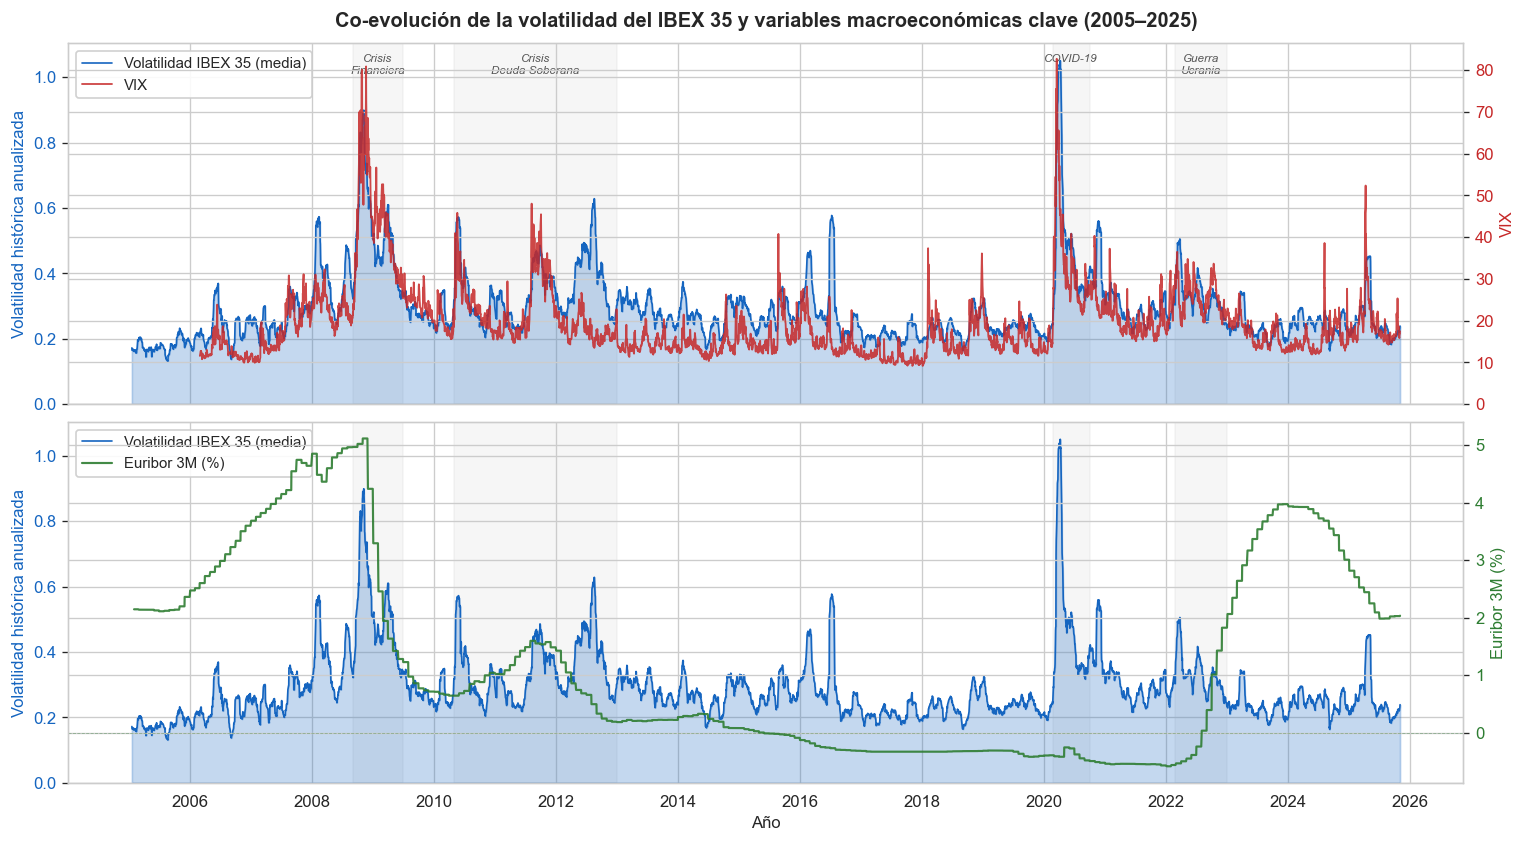

Figura guardada: 10_volatilidad_vix_euribor.png


In [28]:
# ── Co-evolución: volatilidad IBEX 35 + VIX + Euribor 3M ──────────────────
# Dos paneles apilados con eje x compartido.
# Panel superior: volatilidad IBEX (eje izq, azul) + VIX (eje der, rojo)
#   → canal de contagio financiero global
# Panel inferior: volatilidad IBEX (eje izq, azul) + Euribor 3M (eje der, verde)
#   → canal de política monetaria

# 1. Preparar series diarias
vol_ibex = df.groupby('fecha')['vol_hist_21d'].mean().reset_index()
vol_ibex.columns = ['fecha', 'vol_media']

macro_d = df.drop_duplicates('fecha').sort_values('fecha').set_index('fecha')
vix_s    = macro_d['vix'].dropna()
eur_s    = macro_d['euribor_3m'].dropna()

# 2. Períodos de crisis para referencia visual
crisis = [
    ('2008-09-01', '2009-06-30', 'Crisis\nFinanciera'),
    ('2010-05-01', '2012-12-31', 'Crisis\nDeuda Soberana'),
    ('2020-02-20', '2020-09-30', 'COVID-19'),
    ('2022-02-24', '2022-12-31', 'Guerra\nUcrania'),
]

# 3. Figura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.subplots_adjust(hspace=0.05)

C_VOL = '#1565C0'   # azul oscuro — volatilidad
C_VIX = '#C62828'   # rojo — VIX
C_EUR = '#2E7D32'   # verde — Euribor

def shade_crisis(ax):
    for s, e, lbl in crisis:
        ax.axvspan(pd.to_datetime(s), pd.to_datetime(e), alpha=0.07, color='grey', zorder=0)

# ── Panel 1: Volatilidad IBEX + VIX ─────────────────────────────────────────
shade_crisis(ax1)

ax1.fill_between(vol_ibex['fecha'], vol_ibex['vol_media'],
                 alpha=0.25, color=C_VOL, zorder=1)
l1, = ax1.plot(vol_ibex['fecha'], vol_ibex['vol_media'],
               color=C_VOL, linewidth=1.0, label='Volatilidad IBEX 35 (media)', zorder=2)
ax1.set_ylabel('Volatilidad histórica anualizada', color=C_VOL, fontsize=10)
ax1.tick_params(axis='y', labelcolor=C_VOL)
ax1.set_ylim(bottom=0)

ax1b = ax1.twinx()
l2, = ax1b.plot(vix_s.index, vix_s.values,
                color=C_VIX, linewidth=1.1, alpha=0.85, label='VIX', zorder=2)
ax1b.set_ylabel('VIX', color=C_VIX, fontsize=10)
ax1b.tick_params(axis='y', labelcolor=C_VIX)
ax1b.set_ylim(bottom=0)

ax1.legend([l1, l2], ['Volatilidad IBEX 35 (media)', 'VIX'],
           loc='upper left', fontsize=9, framealpha=0.9)
ax1.set_title('Co-evolución de la volatilidad del IBEX 35 y variables macroeconómicas clave (2005–2025)',
              fontsize=12, fontweight='bold', pad=10)

# etiquetas de crisis
for s, e, lbl in crisis:
    mid = pd.to_datetime(s) + (pd.to_datetime(e) - pd.to_datetime(s)) / 2
    ymax = ax1.get_ylim()[1]
    ax1.text(mid, ymax * 0.97, lbl, ha='center', va='top',
             fontsize=7, color='#555555', style='italic')

# ── Panel 2: Volatilidad IBEX + Euribor 3M ──────────────────────────────────
shade_crisis(ax2)

ax2.fill_between(vol_ibex['fecha'], vol_ibex['vol_media'],
                 alpha=0.25, color=C_VOL, zorder=1)
l3, = ax2.plot(vol_ibex['fecha'], vol_ibex['vol_media'],
               color=C_VOL, linewidth=1.0, label='Volatilidad IBEX 35 (media)', zorder=2)
ax2.set_ylabel('Volatilidad histórica anualizada', color=C_VOL, fontsize=10)
ax2.tick_params(axis='y', labelcolor=C_VOL)
ax2.set_ylim(bottom=0)

ax2b = ax2.twinx()
l4, = ax2b.plot(eur_s.index, eur_s.values,
                color=C_EUR, linewidth=1.3, alpha=0.9, label='Euribor 3M (%)', zorder=2)
ax2b.axhline(0, color=C_EUR, linewidth=0.5, linestyle='--', alpha=0.4)
ax2b.set_ylabel('Euribor 3M (%)', color=C_EUR, fontsize=10)
ax2b.tick_params(axis='y', labelcolor=C_EUR)

ax2.legend([l3, l4], ['Volatilidad IBEX 35 (media)', 'Euribor 3M (%)'],
           loc='upper left', fontsize=9, framealpha=0.9)

# Formato eje x
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0, ha='center')
ax2.set_xlabel('Año', fontsize=10)

plt.savefig(os.path.join(FIG_DIR, '10_volatilidad_vix_euribor.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figura guardada: 10_volatilidad_vix_euribor.png')

## 16. Detección formal de outliers: IQR y Z-score

In [ ]:

# ── Detección formal de outliers: IQR (1.5×) y Z-score (|z|>3) ──────────────
# Cuantificamos outliers en las variables clave antes de modelizar.
# Criterio financiero: los outliers son señal económica real (crisis),
# NO errores de medición → NO se eliminan.

from scipy.stats import zscore as sp_zscore

TARGET_VARS = ['vol_hist_21d', 'log_ret', 'vix', 'bono_es_10y', 'spread_es_de']
target_vars_available = [v for v in TARGET_VARS if v in df.columns]

results_outlier = []
for var in target_vars_available:
    serie = df[var].dropna()
    # IQR
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    n_iqr = ((serie < lower_iqr) | (serie > upper_iqr)).sum()
    # Z-score
    z = np.abs(sp_zscore(serie))
    n_z = (z > 3).sum()
    results_outlier.append({
        'Variable':           var,
        'N total':            len(serie),
        'Outliers IQR (1.5×)': n_iqr,
        '% IQR':              round(n_iqr / len(serie) * 100, 2),
        'Outliers Z>3':       n_z,
        '% Z>3':              round(n_z / len(serie) * 100, 2),
        'Límite inf. IQR':    round(lower_iqr, 4),
        'Límite sup. IQR':    round(upper_iqr, 4),
    })

df_outliers_summary = pd.DataFrame(results_outlier)
print('=== DETECCIÓN DE OUTLIERS: IQR (1.5×) y Z-SCORE (|z|>3) ===')
print()
print(df_outliers_summary[['Variable', 'N total', 'Outliers IQR (1.5×)', '% IQR',
                            'Outliers Z>3', '% Z>3']].to_string(index=False))
print()
print('DECISIÓN:')
print('  Los outliers corresponden a periodos de crisis (2008, 2020, 2022).')
print('  Son señal económica relevante, NO errores de medición.')
print('  Se mantienen todos los valores: GARCH captura las colas pesadas.')
print('  Modelos de la fase Análisis del Dato usarán datos completos (sin winsorizar).')

# ── Figura 11: Serie temporal + boxplot + distribución con umbrales ──────────
vol_all = df.groupby('fecha')['vol_hist_21d'].mean().dropna()
Q1v, Q3v = vol_all.quantile(0.25), vol_all.quantile(0.75)
IQRv = Q3v - Q1v
upper_v  = Q3v + 1.5 * IQRv
z_limit  = vol_all.mean() + 3 * vol_all.std()
outlier_mask = vol_all > upper_v

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Detección de Outliers — vol_hist_21d (IBEX 35, media diaria)',
             fontsize=12, fontweight='bold')

# Panel 1: serie temporal con outliers marcados
axes[0].plot(vol_all.index, vol_all.values,
             color=COLORS[0], linewidth=0.6, alpha=0.7, label='Volatilidad media')
axes[0].scatter(vol_all.index[outlier_mask], vol_all.values[outlier_mask],
                color='red', s=12, zorder=5, label=f'Outliers IQR (n={outlier_mask.sum()})')
axes[0].axhline(upper_v, color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Límite sup.={upper_v:.3f}')
axes[0].set_title('Serie temporal — outliers IQR marcados')
axes[0].set_ylabel('Volatilidad anualizada')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(4))

# Panel 2: boxplots por muestra de empresas (10 primeras)
sample_tickers = sorted(df['ticker'].unique())[:10]
data_box = [df[df['ticker'] == t]['vol_hist_21d'].dropna().values for t in sample_tickers]
bp = axes[1].boxplot(data_box, patch_artist=True, showfliers=True,
                     flierprops=dict(marker='.', markersize=3, alpha=0.3, color='red'))
for patch in bp['boxes']:
    patch.set_facecolor(COLORS[0])
    patch.set_alpha(0.6)
axes[1].set_xticks(range(1, len(sample_tickers) + 1))
axes[1].set_xticklabels(sample_tickers, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Boxplot por empresa (muestra 10)')
axes[1].set_ylabel('Volatilidad anualizada')

# Panel 3: distribución con umbrales IQR y Z=3
axes[2].hist(vol_all.values, bins=80, density=True,
             color=COLORS[0], alpha=0.7, edgecolor='none')
axes[2].axvline(upper_v, color='red',    linestyle='--', linewidth=1.5,
                label=f'IQR 1.5× = {upper_v:.3f}')
axes[2].axvline(z_limit, color='orange', linestyle='--', linewidth=1.5,
                label=f'Z=3  = {z_limit:.3f}')
axes[2].set_title('Distribución: umbrales IQR y Z=3')
axes[2].set_xlabel('Volatilidad anualizada')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '11_outliers_iqr_zscore.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 11_outliers_iqr_zscore.png')


## 17. Test de normalidad Jarque-Bera

In [ ]:

# ── Test de normalidad Jarque-Bera ───────────────────────────────────────────
# H0: la serie sigue distribución normal  (JB ~ chi^2(2) bajo H0)
# Rechazamos H0 si p-valor < 0.05

from scipy.stats import jarque_bera

macro_u = df.drop_duplicates('fecha').sort_values('fecha')
vol_u   = df.groupby('fecha')['vol_hist_21d'].mean()
lr_u    = df['log_ret'].dropna()

series_jb = {
    'vol_hist_21d': vol_u.dropna(),
    'log_ret':      lr_u,
    'vix':          macro_u['vix'].dropna(),
    'bono_es_10y':  macro_u['bono_es_10y'].dropna(),
    'euribor_3m':   macro_u['euribor_3m'].dropna(),
    'spread_es_de': macro_u['spread_es_de'].dropna(),
    'ipc_yoy':      macro_u['ipc_yoy'].dropna(),
    'pib_yoy':      macro_u['pib_yoy'].dropna(),
    'brent':        macro_u['brent'].dropna(),
}

jb_results = []
for var, serie in series_jb.items():
    jb_stat, jb_p = jarque_bera(serie)
    skew_v = serie.skew()
    kurt_v = serie.kurtosis() + 3   # curtosis de Fisher (Normal=3)
    normal = 'NO' if jb_p < 0.05 else 'SI'
    jb_results.append({
        'Variable':         var,
        'N':                len(serie),
        'JB estadístico':   round(jb_stat, 1),
        'p-valor':          f'{jb_p:.4f}' if jb_p >= 0.0001 else '<0.0001',
        '¿Normal?':         normal,
        'Asimetría':        round(skew_v, 3),
        'Curtosis (Fisher)': round(kurt_v, 2),
    })

df_jb = pd.DataFrame(jb_results)
print('=== TEST JARQUE-BERA DE NORMALIDAD ===')
print('H0: la distribución es normal  |  Rechazo H0 si p < 0.05')
print()
print(df_jb.to_string(index=False))
print()
print('CONCLUSIONES:')
print('  Todas las series financieras rechazan la normalidad (colas pesadas).')
print('  log_ret tiene curtosis >> 3: leptocurtosis → justifica uso de GARCH.')
print('  Variables macro de baja frecuencia (PIB, IPC) presentan menor desviación.')

# ── Figura 12: QQ-plots 2×2 ─────────────────────────────────────────────────
vars_qq = ['vol_hist_21d', 'log_ret', 'vix', 'brent']
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('QQ-Plots vs distribución normal — Test Jarque-Bera', fontsize=12, fontweight='bold')

for ax, var in zip(axes.flat, vars_qq):
    serie = series_jb[var]
    (osm, osr), (slope, intercept, r) = stats.probplot(serie, dist='norm')
    ax.scatter(osm, osr, s=4, alpha=0.3, color=COLORS[0], label='Datos')
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2, label='Línea normal')
    row = df_jb[df_jb['Variable'] == var].iloc[0]
    ax.text(0.03, 0.95,
            f'JB={row["JB estadístico"]:.0f}\n'
            f'p={row["p-valor"]}\n'
            f'Asim.={row["Asimetría"]}\n'
            f'Kurt.={row["Curtosis (Fisher)"]:.1f}',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_title(f'{var}', fontsize=10)
    ax.set_xlabel('Cuantiles teóricos (Normal)')
    ax.set_ylabel('Cuantiles observados')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '12_jarque_bera_qqplots.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 12_jarque_bera_qqplots.png')


## 18. Cross-correlación con retardos — ¿Lidera la macro a la volatilidad?

In [ ]:

# ── Cross-correlación con retardos: macro → volatilidad ─────────────────────
# Lag > 0: la variable macro lidera la volatilidad en 'lag' días de trading
# Interpretación: si CCF es máxima a lag=5, la macro "anticipa" 5 días a la vol.

from statsmodels.tsa.stattools import ccf

# Series diarias alineadas
vol_series = df.groupby('fecha')['vol_hist_21d'].mean()
macro_d2 = df.drop_duplicates('fecha').sort_values('fecha').set_index('fecha')

common_idx = vol_series.index.intersection(macro_d2.index)
vol_aligned = vol_series.loc[common_idx]
macro_aligned = macro_d2.loc[common_idx]

VARS_CCF = ['vix', 'bono_es_10y', 'spread_es_de', 'euribor_3m', 'brent', 'ipc_yoy']
MAX_LAG = 60

ccf_results = {}
for var in VARS_CCF:
    serie = macro_aligned[var].dropna()
    common = vol_aligned.index.intersection(serie.index)
    if len(common) > 100:
        ccf_vals = ccf(serie.loc[common].values, vol_aligned.loc[common].values,
                       nlags=MAX_LAG, alpha=None)
        ccf_results[var] = ccf_vals[:MAX_LAG + 1]

# Tabla resumen
print('=== CROSS-CORRELACIÓN (MACRO → VOLATILIDAD IBEX) ===')
print('Lag > 0: la variable macro precede (lidera) a la volatilidad')
print()
conf_bound = 1.96 / np.sqrt(len(common_idx))
print(f'Banda de confianza 95%: ±{conf_bound:.4f}')
print()
for var, vals in ccf_results.items():
    max_lag = int(np.argmax(np.abs(vals)))
    max_corr = vals[max_lag]
    sig = '**' if abs(max_corr) > conf_bound else '  '
    print(f'{sig} {var:<15}: CCF_max={max_corr:+.3f}  en lag={max_lag:>3} días')

print()
print('INTERPRETACIÓN:')
print('  ** = significativo (|CCF| > banda 95%)')
print('  Lag=0 significa contemporáneo (mismo día)')
print('  VIX y spread suelen liderar volatilidad IBEX varios días')

# ── Figura 13: CCF por variable ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(
    'Cross-correlación con retardos: Variables macro → Volatilidad IBEX 35\n'
    '(Lag > 0: la macro precede a la volatilidad)',
    fontsize=11, fontweight='bold')

for ax, (var, vals) in zip(axes.flat, ccf_results.items()):
    lags = np.arange(len(vals))
    bar_colors = [COLORS[0] if v >= 0 else COLORS[3] for v in vals]
    ax.bar(lags, vals, color=bar_colors, alpha=0.75, width=0.8)
    ax.axhline(conf_bound,  color='red', linestyle='--', linewidth=1, alpha=0.7, label='IC 95%')
    ax.axhline(-conf_bound, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    max_lag = int(np.argmax(np.abs(vals)))
    ax.axvline(max_lag, color='green', linestyle='-', linewidth=1.5, alpha=0.7,
               label=f'Max lag={max_lag}')
    ax.set_title(f'{var}', fontsize=10)
    ax.set_xlabel('Lag (días)')
    ax.set_ylabel('CCF')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '13_ccf_macro_volatilidad.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 13_ccf_macro_volatilidad.png')


## 19. Test de Kruskal-Wallis — diferencias de volatilidad entre sectores

In [ ]:

# ── Test de Kruskal-Wallis entre sectores ────────────────────────────────────
# H0: la distribución de volatilidad es igual en todos los sectores GICS
# Si rechazamos H0, aplicamos Mann-Whitney U con corrección de Bonferroni

from scipy.stats import kruskal, mannwhitneyu

# Merge usando 'ric' de df_ref (ya tiene formato TICKER.MC)
df_ref_sec = df_ref[['ric', 'sector']].dropna()
df_ref_sec = df_ref_sec.rename(columns={'ric': 'ticker'})
df_ref_sec = df_ref_sec[df_ref_sec['ticker'] != 'Totals (35)']

df_sec = df.merge(df_ref_sec, on='ticker', how='left')

print('Verificación merge sectores:')
print(f'  Filas con sector no nulo: {df_sec["sector"].notna().sum():,}')
print(f'  Sectores: {df_sec["sector"].nunique()}')
print(f'  Lista: {sorted(df_sec["sector"].dropna().unique())}')
print()

# Agrupar por sector
sector_groups = {
    sector: df_sec[df_sec['sector'] == sector]['vol_hist_21d'].dropna().values
    for sector in sorted(df_sec['sector'].dropna().unique())
}
sector_groups = {k: v for k, v in sector_groups.items() if len(v) > 30}

if len(sector_groups) >= 2:
    # Kruskal-Wallis
    kw_stat, kw_p = kruskal(*sector_groups.values())
    print(f'=== TEST KRUSKAL-WALLIS (K={len(sector_groups)} sectores) ===')
    print(f'H0: distribución de volatilidad igual en todos los sectores')
    print(f'Estadístico H = {kw_stat:.2f},  p-valor = {kw_p:.6f}')
    print(f'Resultado: {"RECHAZAMOS H0 (p<0.05) — diferencias significativas" if kw_p < 0.05 else "No rechazamos H0"}')
    print()

    # Estadísticos descriptivos por sector
    print('Estadísticos de volatilidad por sector:')
    for sec, vals in sector_groups.items():
        print(f'  {sec:<30}: n={len(vals):,}  media={np.mean(vals):.4f}  mediana={np.median(vals):.4f}  std={np.std(vals):.4f}')
    print()

    # Post-hoc Mann-Whitney con Bonferroni
    if kw_p < 0.05:
        sectors_list = list(sector_groups.keys())
        n_comparisons = len(sectors_list) * (len(sectors_list) - 1) // 2
        alpha_bonf = 0.05 / n_comparisons
        print(f'Post-hoc Mann-Whitney U (Bonferroni  alpha={alpha_bonf:.4f},  {n_comparisons} comparaciones):')
        sig_pairs = []
        for i in range(len(sectors_list)):
            for j in range(i + 1, len(sectors_list)):
                s1, s2 = sectors_list[i], sectors_list[j]
                mw_stat, mw_p = mannwhitneyu(sector_groups[s1], sector_groups[s2], alternative='two-sided')
                if mw_p < alpha_bonf:
                    sig_pairs.append((s1, s2, mw_p))
        print(f'  Pares significativamente distintos: {len(sig_pairs)}')
        for s1, s2, p in sorted(sig_pairs, key=lambda x: x[2])[:10]:
            print(f'    {s1} vs {s2}: p={p:.6f}')
else:
    print('Insuficientes sectores para el test (revisar merge)')

# ── Figura 14: Boxplot de volatilidad por sector ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
sector_data_sorted = sorted(sector_groups.items(), key=lambda x: np.median(x[1]))

bp = ax.boxplot(
    [vals for _, vals in sector_data_sorted],
    patch_artist=True, showfliers=False, vert=True)
for patch, color in zip(bp['boxes'], sns.color_palette('deep', len(sector_data_sorted))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(sector_data_sorted) + 1))
ax.set_xticklabels([sec for sec, _ in sector_data_sorted], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Volatilidad histórica anualizada')
ax.set_title(
    f'Distribución de volatilidad por sector GICS — Test Kruskal-Wallis\n'
    f'H={kw_stat:.1f},  p={kw_p:.4f}  →  '
    f'{"Diferencias significativas entre sectores (p<0.05)" if kw_p < 0.05 else "Sin diferencias significativas"}',
    fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '14_kruskal_wallis_sectores.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 14_kruskal_wallis_sectores.png')


## 20. Tabla de decisión — tratamiento y retención de variables

In [ ]:

# ── Tabla de decisión de variables ──────────────────────────────────────────
# Justificación formal del tratamiento aplicado a cada variable del dataset

decision_vars = [
    # (Variable, % Nulos, Período, Frecuencia, Razón nulos, Tratamiento, Decisión, Justificación)
    ('close',        '0.0%', '2005–2025', 'Diaria',            'Sin nulos (8 interpolados)',               'Interpolación lineal',      'MANTENER',       'Variable origen de vol_hist_21d'),
    ('log_ret',      '0.0%', '2005–2025', 'Diaria',            'NaN primer obs. por empresa',             'Normal',                    'MANTENER',       'Retorno estacionario; input para volatilidad'),
    ('vol_hist_21d', '0.2%', '2005–2025', 'Diaria',            'Warm-up ventana 21 días',                 'Normal (inicio de serie)',  'MANTENER',       'Variable objetivo principal del TFG'),
    ('vix',          '3.8%', '2005–2025', 'Diaria',            'Festivos EEUU / gaps mercado',            'Forward-fill',              'MANTENER',       'Mayor correlación con vol. IBEX (r≈0.7)'),
    ('bono_es_10y',  '10.3%','2005–2025', 'Diaria',            'Días sin cotización bono',                'Forward-fill',              'MANTENER',       'Indicador clave condiciones monetarias ES'),
    ('bono_de_10y',  '10.3%','2005–2025', 'Diaria',            'Días sin cotización bono',                'Forward-fill',              'MANTENER',       'Referencia risk-free zona euro'),
    ('spread_es_de', '47.4%','2014–2025', 'Diaria',            'Disponible solo desde 2014',              'Forward-fill; NaN antes',   'MANTENER',       'Proxy riesgo soberano; relevante crisis deuda'),
    ('eur_usd',      '0.0%', '2005–2025', 'Diaria',            'Sin nulos significativos',                'Normal',                    'MANTENER',       'Canal tipo de cambio exportaciones IBEX'),
    ('euribor_3m',   '0.2%', '2005–2025', 'Mensual→Diaria',   'Forward-fill mensual a diario',           'Forward-fill',              'MANTENER',       'Tipo referencia crédito eurozona'),
    ('euribor_6m',   '0.2%', '2005–2025', 'Mensual→Diaria',   'Forward-fill mensual a diario',           'Forward-fill',              'MANTENER',       'Complementa Euribor 3M (r>0.99 entre ambos)'),
    ('tipo_dfr',     '13.5%','2009–2025', 'Mensual→Diaria',   'BCE inició serie post-2008',              'Forward-fill',              'MANTENER',       'Decisiones política monetaria BCE'),
    ('tipo_mlf',     '13.5%','2009–2025', 'Mensual→Diaria',   'Ídem tipo_dfr',                           'Forward-fill',              'REDUNDANTE',     'Colinealidad perfecta con tipo_dfr; excluir en modelos'),
    ('tipo_mro',     '13.5%','2009–2025', 'Mensual→Diaria',   'Ídem tipo_dfr',                           'Forward-fill',              'REDUNDANTE',     'Colinealidad perfecta con tipo_dfr; excluir en modelos'),
    ('ipc_yoy',      '29.1%','2008–2025', 'Mensual→Diaria',   'Dato disponible desde 2008',              'Forward-fill',              'MANTENER',       'Canal inflación → tipos → volatilidad'),
    ('ipc_sub_mom',  '0.0%', '2005–2025', 'Mensual→Diaria',   'Sin nulos',                               'Forward-fill',              'MANTENER',       'Inflación subyacente; presiones de demanda'),
    ('pib_yoy',      '0.8%', '2005–2025', 'Trimestral→Diaria','Forward-fill trimestral',                 'Forward-fill',              'MANTENER',       'Ciclo económico; alta corr. con tasa_paro'),
    ('tasa_paro',    '0.8%', '2005–2025', 'Trimestral→Diaria','Forward-fill trimestral',                 'Forward-fill',              'MANTENER',       'Mercado laboral español; complementa PIB'),
    ('ipi_yoy',      '0.0%', '2005–2025', 'Mensual→Diaria',   'Sin nulos',                               'Forward-fill',              'MANTENER',       'Actividad industrial; coincide con PMI'),
    ('pmi',          '83.2%','2023–2025', 'Mensual→Diaria',   'Solo 36 obs. disponibles',                'Forward-fill',              'USO LIMITADO',   'Cobertura insuficiente (3 años); no usar como predictor'),
    ('vibex',        '60.9%','2015–2025', 'Diaria',            'VIBEX creado post-Brexit (2015)',         'NaN antes 2015',            'MANTENER',       'Vol. implícita IBEX 35; más específico que VIX'),
    ('vstoxx',       '32.1%','2009–2025', 'Diaria',            'Disponible desde 2009',                   'NaN antes 2009',            'MANTENER',       'Vol. implícita eurozona; canal contagio'),
    ('brent',        '4.9%', '2005–2025', 'Diaria',            'Festivos commodity / gaps',               'Forward-fill',              'MANTENER',       'Shock energético; sector energía >15% IBEX'),
    ('gas_ttf',      '19.5%','2010–2025', 'Diaria',            'Serie completa desde 2010',               'Forward-fill',              'MANTENER',       'Clave crisis energética 2021-22'),
]

cols = ['Variable', '% Nulos', 'Período', 'Frecuencia', 'Razón nulos', 'Tratamiento', 'Decisión', 'Justificación']
df_decision = pd.DataFrame(decision_vars, columns=cols)

print('=== TABLA DE DECISIÓN — TRATAMIENTO Y RETENCIÓN DE VARIABLES ===')
print()
print(df_decision[['Variable','% Nulos','Período','Decisión','Justificación']].to_string(index=False))
print()

for dec in ['MANTENER', 'REDUNDANTE', 'USO LIMITADO']:
    v = df_decision[df_decision['Decisión'] == dec]['Variable'].tolist()
    print(f'{dec} ({len(v)}): {v}')

print()
print('VARIABLES REDUNDANTES: tipo_mlf y tipo_mro son linealmente dependientes')
print('de tipo_dfr (BCE anuncia los tres simultáneamente). Se mantienen en el')
print('dataset bruto pero quedan excluidos de los features de los modelos predictivos.')
print()
print('PMI: 83.2% de nulos porque Reuters Eikon solo dispone de 36 observaciones')
print('mensuales (2023-2025). Cobertura insuficiente para modelos de 20 años.')
print('Se mantiene en el dataset para análisis descriptivo reciente.')
